# Previsão de Preços de Ações com LSTM + GRU
## Projeto Acadêmico — Deep Learning Aplicado a Finanças

---

Este projeto aplica uma arquitetura híbrida **LSTM + GRU** (implementada em PyTorch) para prever preços de fechamento de **4 ações da B3**, utilizando dados históricos e indicadores técnicos como features.

**Ações analisadas:** PETR4.SA, BBAS3.SA, WEGE3.SA, ABEV3.SA  
**Período:** 2019-01-01 até hoje  
**Features:** Preço de Fechamento (Close), SMA_14, EMA_14, RSI_14  
**Meta de desempenho:** R² > 0.83 em cada ativo

---

### Por que estas 4 ações?

| Ação | Setor | Por que foi escolhida |
|------|-------|----------------------|
| PETR4.SA | Energia / Petróleo | Altamente correlacionada ao USD/BRL e ao Brent; volatilidade influenciada por risco político e geopolítico |
| BBAS3.SA | Bancário | Sensível à taxa SELIC e ciclos de crédito; apresenta padrão sazonal de distribuição de dividendos |
| WEGE3.SA | Industrial / Exportador | Receita em USD com crescimento consistente; menor ruído especulativo, tendências mais longas |
| ABEV3.SA | Consumo Defensivo | Sazonalidade bem definida (verão/Carnaval); comportamento descorrelacionado dos demais setores |

A seleção cobre **4 dinâmicas de mercado distintas**, permitindo avaliar a robustez da arquitetura em diferentes regimes de volatilidade e padrões de preço.

## Contexto e Motivação — Para o Assessor de Investimentos

---

### Por que usar Deep Learning para prever preços de ações?

Antes de mais nada, uma premissa importante: **este modelo não tenta "adivinhar" o preço de amanhã com certeza**. Nenhum modelo consegue isso — o mercado é influenciado por notícias, eventos políticos e comportamento humano imprevisível.

O que o modelo faz é **aprender padrões históricos** que tendem a se repetir. Assim como um analista experiente reconhece que "quando a SELIC sobe acima de X%, bancos costumam ter comportamento Y nos próximos meses", o modelo aprende automaticamente esses padrões — e muitos outros que seriam impossíveis de identificar manualmente.

**Utilidade prática:**
- Identificar tendências de médio prazo (semanas)
- Quantificar o grau de previsibilidade de cada ativo
- Fornecer uma referência quantitativa para complementar análise fundamentalista

---

### Por que 4 ações de setores diferentes?

Cada setor tem sua própria "linguagem" de preços:

- **Petróleo (PETR4):** responde ao dólar, ao barril de Brent e ao risco-Brasil
- **Bancos (BBAS3):** respondem à SELIC, inadimplência e crédito
- **Industrial/Exportador (WEGE3):** cresce junto com o câmbio e exportações
- **Consumo (ABEV3):** responde à renda e sazonalidade de consumo

Usar 4 setores distintos demonstra que a arquitetura é **generalista** — funciona bem independentemente da dinâmica do ativo.

---

### Por que não usar um único modelo para todas as ações?

Um único modelo tentaria aprender os padrões de todos os ativos ao mesmo tempo. O problema: esses padrões frequentemente são **opostos**.

Quando o dólar sobe:
- PETR4 tende a **subir** (receita em dólar)
- BBAS3 pode **cair** (câmbio alto pressiona inadimplência e reduz crédito)

Um modelo único "mediaria" esses padrões opostos e acabaria sendo ruim nos dois casos.

**Analogia:** Um analista especializado em petróleo não seria o ideal para analisar o setor bancário — e vice-versa. Modelos separados = **especialização**.

In [43]:
# Instalação das dependências
# Execute esta célula primeiro no Google Colab
!pip install yfinance scikit-learn torch matplotlib pandas numpy --quiet

In [44]:
# =============================================================================
# IMPORTS E CONFIGURAÇÃO INICIAL
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import copy
import warnings
warnings.filterwarnings('ignore')

try:
    import yfinance as yf
except ImportError:
    raise ImportError("Execute: !pip install yfinance")

# ─── SEED FIXA ───────────────────────────────────────────────────────────────
# Por que seed fixa? Reprodutibilidade = validade científica.
# Com SEED=42, qualquer pessoa que execute este notebook obterá
# exatamente os mesmos pesos iniciais, mesma ordem de batches e
# mesmos resultados — condição necessária para um experimento científico
# ser considerado reprodutível e verificável por terceiros.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ─── DEVICE ──────────────────────────────────────────────────────────────────
# GPU acelera o treinamento em até 10-50x para modelos recorrentes.
# No Colab: Runtime > Change runtime type > T4 GPU para ativar.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo ativo: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  Dica: Ative GPU no Colab para treinamento mais rápido.")
    print("  Runtime > Change runtime type > T4 GPU")

Dispositivo ativo: cpu
  Dica: Ative GPU no Colab para treinamento mais rápido.
  Runtime > Change runtime type > T4 GPU


## Hiperparâmetros — O que São e Por que Cada Valor

---

As "configurações" do modelo, decididas **antes** do treinamento, com base em experiência, literatura e experimentação.

| Hiperparâmetro | Valor | Valor técnico | Em linguagem simples |
|----------------|-------|---------------|---------------------|
| `SEQ_LEN` | 60 | Janela temporal de entrada (timesteps) | O modelo lê os últimos **60 pregões** (~3 meses) antes de prever |
| `TRAIN_RATIO` | 0.80 | Proporção treino/teste | **80% dos dados** para treinar, 20% para avaliar |
| `HIDDEN_LSTM` | 128 | Dimensão do estado oculto do LSTM | Capacidade de memória do "Analista LSTM" — 128 "notas" simultâneas |
| `HIDDEN_GRU` | 64 | Dimensão do estado oculto do GRU | Síntese mais compacta — o GRU condensa em 64 dimensões |
| `NUM_LAYERS_LSTM` | 2 | Número de camadas empilhadas no LSTM | 2 analistas em série — o segundo analisa o resumo do primeiro |
| `DROPOUT` | 0.2 | Taxa de desativação aleatória de neurônios | 20% das "notas" são ocultadas durante o treino — evita memorização |
| `BATCH_SIZE` | 32 | Amostras por atualização de pesos | O modelo corrige os pesos a cada 32 exemplos vistos |
| `LEARNING_RATE` | 0.001 | Taxa de aprendizado inicial do Adam | Tamanho do "passo" na correção de erros — nem grande demais, nem pequeno demais |
| `EPOCHS` | 150 | Número máximo de passagens completas pelos dados | Limite de "dias de estudo" — o Early Stopping pode interromper antes |
| `PATIENCE_ES` | 20 | Épocas sem melhora antes do Early Stopping | Se 20 épocas passarem sem progresso, encerramos o treino |
| `PATIENCE_LR` | 10 | Épocas sem melhora antes de reduzir o LR | Após 10 épocas estagnadas, reduzimos o tamanho do passo à metade |
| `N_FUTURE` | 7 | Dias úteis futuros a prever | Horizonte de previsão: **1 semana de pregão** à frente |

In [45]:
# HIPERPARÂMETROS E CONFIGURAÇÕES GLOBAIS

# 4 setores distintos: petróleo, bancário, industrial, consumo defensivo
TICKERS = ['PETR4.SA', 'BBAS3.SA', 'WEGE3.SA', 'ABEV3.SA']

# ─── PERÍODO DOS DADOS ───────────────────────────────────────────────────────
# 2019 em diante: inclui pré-pandemia, pandemia e recuperação
# Isso garante que o modelo aprenda em diferentes regimes de mercado
DATA_INICIO = '2019-01-01'
DATA_FIM = pd.Timestamp.today().strftime('%Y-%m-%d')  # sempre atualizado

# ─── JANELA TEMPORAL ─────────────────────────────────────────────────────────
# SEQ_LEN=60: ~3 meses de pregão (20 dias/mês × 3)
# Análogo a um analista que abre os relatórios dos últimos 3 meses
# antes de fazer uma recomendação
SEQ_LEN = 60

# ─── SPLIT TREINO/TESTE ───────────────────────────────────────────────────────
# 80% treino (passado mais distante), 20% teste (período mais recente)
# Divisão temporal — nunca aleatória em séries temporais!
TRAIN_RATIO = 0.80

# ─── ARQUITETURA DO MODELO ────────────────────────────────────────────────────
# LSTM com 128 unidades: capacidade de capturar dependências longas
HIDDEN_LSTM = 128
# GRU com 64 unidades: bottleneck que comprime a representação (evita overfitting)
HIDDEN_GRU = 64
# 2 camadas LSTM empilhadas: primeira aprende padrões de curto prazo,
# segunda aprende padrões de médio/longo prazo sobre a primeira
NUM_LAYERS_LSTM = 2
# Dropout 20%: regularização — força o modelo a não depender de neurônios específicos
DROPOUT = 0.2

# ─── TREINAMENTO ─────────────────────────────────────────────────────────────
# Batch de 32: balanceamento entre estabilidade do gradiente e velocidade
BATCH_SIZE = 32
# LR 0.001: padrão consolidado para Adam com redes recorrentes financeiras
LEARNING_RATE = 0.001
# 150 épocas máximo: Early Stopping interromperá antes se necessário
EPOCHS = 150
# Paciência de 20 épocas para Early Stopping
PATIENCE_ES = 20
# Paciência de 10 épocas para ReduceLROnPlateau
PATIENCE_LR = 10
# Redução do LR por fator 0.5 (divide pela metade)
FACTOR_LR = 0.5
# Clipping do gradiente: evita explosão de gradiente (instabilidade numérica)
MAX_NORM = 1.0

# ─── FEATURES ────────────────────────────────────────────────────────────────
# Close: preço real | SMA_14/EMA_14: tendência | RSI_14: momentum
FEATURE_COLS = ['Close', 'SMA_14', 'EMA_14', 'RSI_14']
N_FEATURES = len(FEATURE_COLS)  # = 4

# ─── HORIZONTE DE PREVISÃO ────────────────────────────────────────────────────
# 7 dias úteis = 1 semana de pregão
# Horizonte razoável: dias 1-3 mais confiáveis, 6-7 com maior incerteza
N_FUTURE = 7

print(f"Período dos dados: {DATA_INICIO} → {DATA_FIM}")
print(f"Ativos: {', '.join(TICKERS)}")
print(f"Features: {', '.join(FEATURE_COLS)}")
print(f"Janela temporal: {SEQ_LEN} pregões")
print(f"Horizonte de previsão: {N_FUTURE} dias úteis")

Período dos dados: 2019-01-01 → 2026-03-27
Ativos: PETR4.SA, BBAS3.SA, WEGE3.SA, ABEV3.SA
Features: Close, SMA_14, EMA_14, RSI_14
Janela temporal: 60 pregões
Horizonte de previsão: 7 dias úteis


## Indicadores Técnicos — O "Vocabulário" do Mercado

---

### Para o Assessor de Investimentos

O modelo não usa apenas o preço de fechamento. Ele também recebe **indicadores técnicos** — resumos matemáticos do comportamento recente do ativo. Pense neles como "perguntas que o modelo faz sobre o mercado":

| Indicador | O que é | Analogia |
|-----------|---------|----------|
| **SMA_14** | Média Simples dos últimos 14 fechamentos | "Qual foi o preço médio nas últimas 3 semanas?" |
| **EMA_14** | Média Exponencial — dias recentes pesam mais | "O que aconteceu esta semana importa mais que o início do mês" |
| **RSI_14** | Índice de Força Relativa — mede momentum | "O mercado ainda tem energia para subir, ou já está esgotado?" |

**Por que o RSI é especialmente útil?** Ele identifica situações de sobrecompra (RSI > 70: "todos já compraram, quem mais vai comprar?") e sobrevenda (RSI < 30: "as vendas podem estar exageradas, possível reversão").

---

### Fórmulas Matemáticas

**SMA (Simple Moving Average):**
$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

**EMA (Exponential Moving Average):**
$$\text{EMA}_t = P_t \cdot \alpha + \text{EMA}_{t-1} \cdot (1 - \alpha), \quad \alpha = \frac{2}{n+1}$$

**RSI (Relative Strength Index):**
$$\text{RSI} = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\overline{\text{Ganhos}_{14}}}{\overline{\text{Perdas}_{14}}}$$

Onde $\overline{\text{Ganhos}}$ e $\overline{\text{Perdas}}$ são médias exponenciais das variações positivas e negativas respectivamente.

Usamos `com = n - 1` no EMA do RSI (equivalente a `alpha = 1/n`), seguindo a formulação original de Wilder (1978).

In [46]:
# FUNÇÕES DE INDICADORES TÉCNICOS

def calcular_sma(serie: pd.Series, janela: int) -> pd.Series:
    """
    Calcula a Média Móvel Simples (SMA).

    O QUE FAZ: Calcula a média aritmética dos últimos `janela` valores.
    Cada ponto recebe o mesmo peso.

    POR QUÊ: Suaviza ruídos de curto prazo, revelando a tendência
    subjacente. Quando o preço está acima da SMA, indica tendência de alta.

    ANALOGIA DE NEGÓCIO: "Qual foi o preço médio desta ação nas últimas
    3 semanas?" — uma referência simples de nível de preço recente.

    Args:
        serie: Série temporal de preços (tipicamente Close).
        janela: Número de períodos para a média (14 pregões ≈ 3 semanas).

    Returns:
        Série com a SMA calculada. Primeiros (janela-1) valores serão NaN.
    """
    return serie.rolling(window=janela).mean()


def calcular_ema(serie: pd.Series, janela: int) -> pd.Series:
    """
    Calcula a Média Móvel Exponencial (EMA).

    O QUE FAZ: Média ponderada onde dados recentes recebem peso maior.
    Fator de suavização: alpha = 2 / (janela + 1).
    Implementado via ewm(span=janela, adjust=False) — equivalente exato.

    POR QUÊ: Mais responsiva a movimentos recentes que a SMA.
    Captura reversões de tendência mais cedo.

    ANALOGIA DE NEGÓCIO: "O que aconteceu esta semana importa mais
    do que o que aconteceu há 3 semanas." — ideal para mercados voláteis.

    Args:
        serie: Série temporal de preços.
        janela: Span da EMA (14 pregões).

    Returns:
        Série com a EMA calculada. Sem NaNs iniciais (EMA começa do primeiro valor).
    """
    return serie.ewm(span=janela, adjust=False).mean()


def calcular_rsi(serie: pd.Series, janela: int = 14) -> pd.Series:
    """
    Calcula o Índice de Força Relativa (RSI) — Wilder (1978).

    O QUE FAZ: Mede a velocidade e magnitude das variações de preço.
    RSI = 100 - (100 / (1 + RS)), onde RS = EMA(ganhos) / EMA(perdas).
    Intervalo: [0, 100].

    POR QUÊ: Identifica condições de sobrecompra (RSI > 70) e sobrevenda
    (RSI < 30), além de medir o "momentum" da tendência atual.

    ANALOGIA DE NEGÓCIO:
    - RSI > 70: "O mercado comprou demais — pode estar esgotando a alta."
    - RSI < 30: "O mercado vendeu demais — possível reversão de alta."
    - RSI = 50: "Equilíbrio entre compradores e vendedores."

    Args:
        serie: Série temporal de preços de fechamento.
        janela: Período do RSI (padrão: 14 pregões, conforme Wilder).

    Returns:
        Série RSI no intervalo [0, 100].
    """
    delta = serie.diff()                          # variação diária
    ganhos = delta.clip(lower=0)                  # apenas dias positivos
    perdas = -delta.clip(upper=0)                 # apenas dias negativos (positivos)
    # EMA de Wilder: com = janela - 1 ≡ alpha = 1/janela
    media_ganhos = ganhos.ewm(com=janela - 1, adjust=False).mean()
    media_perdas = perdas.ewm(com=janela - 1, adjust=False).mean()
    rs = media_ganhos / (media_perdas + 1e-10)    # +1e-10 evita divisão por zero
    return 100 - (100 / (1 + rs))


print("Funções de indicadores técnicos carregadas: SMA, EMA, RSI")

Funções de indicadores técnicos carregadas: SMA, EMA, RSI


## Download e Preparação dos Dados

---

### Detalhes técnicos do download

**`auto_adjust=True`:** O yfinance ajusta automaticamente os preços históricos para eventos corporativos (desdobramentos, dividendos). Sem isso, um desdobramento 1:10 criaria uma "queda artificial" de 90% no preço — o modelo confundiria evento corporativo com crise.

**MultiIndex:** versões recentes do yfinance retornam um DataFrame com índice de coluna duplo `(campo, ticker)`. Detectamos e achatamos esse índice para trabalhar com colunas simples.

**`dropna()`:** Os indicadores técnicos SMA e RSI precisam de `janela` dias para calcular o primeiro valor. As primeiras 14 linhas terão NaN — removemos para não alimentar dados inválidos ao modelo.

### Para o assessor

O processo é equivalente a preparar uma planilha: baixamos os dados brutos, calculamos os indicadores e limpamos as linhas incompletas. O modelo só vê dados completos e ajustados.

In [47]:
# DOWNLOAD E PROCESSAMENTO DOS DADOS

def baixar_e_processar_dados(ticker: str) -> pd.DataFrame:
    """
    Baixa dados históricos do ticker e calcula indicadores técnicos.

    O QUE FAZ:
    1. Baixa OHLCV do Yahoo Finance (auto_adjust=True para ajuste de proventos)
    2. Normaliza o MultiIndex caso presente (comportamento do yfinance >= 0.2)
    3. Calcula SMA_14, EMA_14, RSI_14 sobre o preço de fechamento
    4. Remove linhas com NaN (geradas pelos indicadores nas primeiras janelas)

    POR QUÊ auto_adjust=True: ajusta preços históricos para dividendos e
    desdobramentos — sem isso, splits criam descontinuidades artificiais
    que o modelo interpretaria como eventos de mercado.

    Args:
        ticker: Código do ativo no Yahoo Finance (ex: 'PETR4.SA').

    Returns:
        DataFrame com colunas [Close, SMA_14, EMA_14, RSI_14],
        indexado por data (dias úteis apenas).
    """
    print(f"\n  Baixando dados para {ticker}...")

    df = yf.download(ticker, start=DATA_INICIO, end=DATA_FIM,
                     auto_adjust=True, progress=False)

    # Tratar MultiIndex do yfinance >= 0.2
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Manter apenas Close
    df = df[['Close']].copy()
    df.columns = ['Close']

    # Calcular indicadores técnicos
    df['SMA_14'] = calcular_sma(df['Close'], 14)
    df['EMA_14'] = calcular_ema(df['Close'], 14)
    df['RSI_14'] = calcular_rsi(df['Close'], 14)

    # Remover NaNs gerados pelas janelas iniciais
    df.dropna(inplace=True)

    print(f"  Dados: {df.index[0].date()} → {df.index[-1].date()} ({len(df)} dias úteis)")
    print(f"  Features: {list(df.columns)}")

    return df


# Teste rápido com PETR4 para verificar o pipeline de dados
print("Testando download e processamento...")
df_teste = baixar_e_processar_dados('PETR4.SA')
print(f"\nAmostra dos dados (últimas 5 linhas):")
print(df_teste.tail())

Testando download e processamento...

  Baixando dados para PETR4.SA...
  Dados: 2019-01-21 → 2026-03-26 (1787 dias úteis)
  Features: ['Close', 'SMA_14', 'EMA_14', 'RSI_14']

Amostra dos dados (últimas 5 linhas):
                Close     SMA_14     EMA_14     RSI_14
Date                                                  
2026-03-20  45.669998  44.039285  44.229239  72.348575
2026-03-23  46.029999  44.402142  44.469340  73.511358
2026-03-24  47.270000  44.885714  44.842762  77.085667
2026-03-25  47.500000  45.372143  45.197060  77.687087
2026-03-26  48.020000  45.790714  45.573452  79.027337


## Normalização e Janela Deslizante

---

### Nível técnico

**Normalização (MinMaxScaler [0, 1]):**
- Redes neurais são sensíveis à escala dos inputs. Preços de R$5 (ABEV3) e R$40 (PETR4) em mesma escala fariam os gradientes de um ativo dominar o outro.
- **CRÍTICO:** `fit()` é chamado **apenas** nos dados de treino. O scaler aprende o `min` e `max` históricos e aplica essa mesma transformação ao conjunto de teste. Isso evita **data leakage**.
- Data leakage: se o scaler visse o máximo futuro durante o fit, o modelo "trapacearia" — como estudar com o gabarito da prova. Ao fazer inferência real, esse máximo não existiria, invalidando os resultados.

**Janela deslizante (sliding window):**
- Converte a série temporal em amostras supervisionadas: `X[i]` = janela de `SEQ_LEN=60` timesteps, `y[i]` = próximo Close normalizado.
- Shape resultante: `X.shape = (n_amostras, 60, 4)`, `y.shape = (n_amostras,)`
- Para `n` observações totais, gera `n - SEQ_LEN` amostras.

---

### Para o assessor de investimentos

**Normalização:** É como converter temperaturas de Fahrenheit para Celsius — mudamos a escala, não os dados. Fazemos isso para que o modelo não confunda "PETR4 caiu de R$40 para R$38" com "ABEV3 caiu de R$14 para R$13" — em termos percentuais são quedas diferentes, e precisamos que o modelo trate cada ativo na sua própria escala. Normalizamos cada ação separadamente.

**Janela deslizante:** O modelo lê os últimos 60 pregões (~3 meses) antes de fazer uma previsão — como um analista que abre os relatórios dos últimos 3 meses antes de dar uma recomendação. Essa janela "desliza" ao longo de toda a série histórica, criando milhares de exemplos de treinamento.

In [48]:
# =============================================================================
# NORMALIZAÇÃO E DIVISÃO TREINO/TESTE
# =============================================================================

def normalizar_e_dividir(df: pd.DataFrame):
    """
    Normaliza os dados e divide em conjuntos de treino e teste.

    IMPORTANTE: fit() APENAS no treino para evitar data leakage.
    Data leakage: se o scaler visse o máximo futuro, o modelo
    'trapacearia' ao treinar — como estudar com o gabarito da prova.
    Ao fazer inferência real, esse máximo não existiria,
    invalidando completamente os resultados reportados.

    Fluxo:
    1. Extrai as features em array numpy
    2. Divide na proporção TRAIN_RATIO (temporal — não aleatória!)
    3. Ajusta o scaler SOMENTE nos dados de treino
    4. Transforma treino e teste com a mesma escala aprendida

    Args:
        df: DataFrame com colunas FEATURE_COLS.

    Returns:
        train_scaled: array normalizado do treino, shape (n_treino, 4)
        test_scaled:  array normalizado do teste,  shape (n_teste, 4)
        scaler:       MinMaxScaler ajustado (para inversão posterior)
        split_idx:    índice de corte treino/teste no DataFrame original
    """
    valores = df[FEATURE_COLS].values
    split_idx = int(len(valores) * TRAIN_RATIO)

    treino_bruto = valores[:split_idx]
    teste_bruto  = valores[split_idx:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(treino_bruto)             # aprende escala APENAS do passado

    train_scaled = scaler.transform(treino_bruto)
    test_scaled  = scaler.transform(teste_bruto)  # mesma escala do treino

    print(f"  Split: {split_idx} treino | {len(valores) - split_idx} teste")
    print(f"  Scaler ajustado apenas nos dados de treino (anti-leakage)")

    return train_scaled, test_scaled, scaler, split_idx


print("Função de normalização carregada.")

Função de normalização carregada.


In [49]:
# SEQUÊNCIAS E DATASET

def criar_sequencias(dados: np.ndarray, seq_len: int):
    """
    Converte array temporal em pares (X, y) via janela deslizante.

    Para cada posição i:
      X[i] = dados[i : i + seq_len]    → janela de entrada, shape (seq_len, n_features)
      y[i] = dados[i + seq_len, 0]     → próximo Close normalizado (feature index 0)

    Exemplo concreto (seq_len=60, n_features=4):
      X[0] = pregões 0..59  (60 dias, cada um com [Close, SMA, EMA, RSI])
      y[0] = Close do pregão 60 (normalizado)
      X[1] = pregões 1..60
      y[1] = Close do pregão 61
      ...

    Args:
        dados:   Array normalizado, shape (n, n_features).
        seq_len: Tamanho da janela de entrada (SEQ_LEN=60).

    Returns:
        X: np.ndarray float32, shape (n - seq_len, seq_len, n_features)
        y: np.ndarray float32, shape (n - seq_len,)
    """
    X, y = [], []
    for i in range(len(dados) - seq_len):
        X.append(dados[i : i + seq_len])      # janela de entrada
        y.append(dados[i + seq_len, 0])       # alvo: próximo Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class AcoesDataset(Dataset):
    """
    Dataset PyTorch para séries temporais de ações.

    POR QUÊ herdar Dataset: permite uso com DataLoader, que automatiza
    batching, shuffle e carregamento paralelo — essencial para treinamento
    eficiente em GPU.

    POR QUÊ float32: GPUs são otimizadas para float32. float64 seria
    mais preciso, mas 2x mais lento sem ganho prático neste contexto.

    Args:
        X: Array de sequências, shape (n_amostras, seq_len, n_features).
        y: Array de alvos, shape (n_amostras,).
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


print("Funções criar_sequencias e AcoesDataset carregadas.")

Funções criar_sequencias e AcoesDataset carregadas.


## A Arquitetura LSTM + GRU

---

### Para o Assessor a interpretação pode ser:

Imagine **dois analistas trabalhando em equipe**, cada um com habilidades complementares:

**Analista LSTM — 2 camadas, 128 unidades:**
- Lê os relatórios dos últimos 3 meses com atenção total.
- **Primeira camada:** identifica padrões de curto prazo ("o preço subiu 3 dias seguidos", "RSI está acima de 60").
- **Segunda camada:** identifica padrões mais longos sobre o resumo da primeira ("desde que o RSI passou de 60 por 3 dias, a tendência durou mais 2 semanas").
- Ele tem um excelente sistema de anotações — decide ativamente o que **lembrar** e o que **esquecer** (os "gates" do LSTM).

**Analista GRU — 64 unidades:**
- Recebe o resumo do LSTM e faz uma síntese mais compacta.
- É mais rápido e eficiente — chega às mesmas conclusões com menos "notas".
- Atua como um **filtro de bottleneck**: força o modelo a manter apenas o que é realmente relevante.

**Dropout (20%):**
- Durante o treinamento, deliberadamente "esconde" 20% das anotações.
- Isso força os analistas a não dependerem de nenhuma informação específica.
- Resultado: análises mais robustas, menos dependentes de um único padrão.

---

### Para o Professor — Detalhes Técnicos

**Fluxo de dimensões:**
```
Input:        (batch, 60, 4)     → 60 timesteps, 4 features
LSTM Layer 1: (batch, 60, 128)   → 128 unidades ocultas por timestep
LSTM Layer 2: (batch, 60, 128)   → segunda camada empilhada
GRU Layer:    (batch, 60, 64)    → compressão para 64 dimensões
Last step:    (batch, 64)        → estado final [seq, -1, :]
Dropout:      (batch, 64)        → regularização 20%
Linear:       (batch, 1)         → Close normalizado previsto
```

**Gates do LSTM:** input gate, forget gate, output gate + cell state.  
**Gates do GRU:** reset gate, update gate (versão simplificada sem cell state separado).  
**Bottleneck LSTM→GRU:** 128→64 dimensões reduz o risco de overfitting na camada final.  
**batch_first=True:** convenção PyTorch — dimensão do batch é a primeira.

In [50]:
# =============================================================================
# ARQUITETURA LSTM + GRU
# =============================================================================

class LSTMGRUModel(nn.Module):
    """
    Arquitetura híbrida LSTM + GRU para previsão de séries temporais financeiras.

    Fluxo:
      (batch, 60, 4)
        → LSTM 2 camadas (hidden=128, dropout=0.2 entre camadas)
        → (batch, 60, 128)
        → GRU 1 camada  (hidden=64)
        → (batch, 60, 64)
        → último timestep: (batch, 64)
        → Dropout(0.2)
        → Linear(64 → 1)
        → (batch,)  [Close normalizado]

    Justificativa da arquitetura:
    - LSTM 2 camadas: captura dependências de curto e médio prazo em hierarquia
    - GRU como bottleneck: comprime representação, reduz overfitting
    - Dropout pós-GRU: regularização adicional antes da camada linear
    - Apenas último timestep do GRU: estado final resume toda a sequência
    """

    def __init__(self, n_features, hidden_lstm, hidden_gru, num_layers, dropout):
        """
        Args:
            n_features:  Número de features de entrada (4: Close, SMA, EMA, RSI).
            hidden_lstm: Dimensão do estado oculto do LSTM (128).
            hidden_gru:  Dimensão do estado oculto do GRU (64).
            num_layers:  Camadas LSTM empilhadas (2).
            dropout:     Taxa de dropout (0.2) — aplicado entre camadas LSTM
                         e antes da camada linear.
        """
        super(LSTMGRUModel, self).__init__()

        # LSTM: 2 camadas empilhadas, dropout entre camadas (só ativo quando num_layers > 1)
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_lstm,
            num_layers=num_layers,
            batch_first=True,       # (batch, seq, feature) — convenção mais intuitiva
            dropout=dropout         # dropout entre as camadas LSTM
        )

        # GRU: 1 camada, recebe saída do LSTM como input
        self.gru = nn.GRU(
            input_size=hidden_lstm,
            hidden_size=hidden_gru,
            num_layers=1,
            batch_first=True
        )

        # Regularização antes da camada de saída
        self.dropout = nn.Dropout(p=dropout)

        # Camada de saída: mapeia representação final para 1 valor (Close previsto)
        self.linear = nn.Linear(hidden_gru, 1)

    def forward(self, x):
        """
        Forward pass.

        Args:
            x: Tensor de entrada, shape (batch, seq_len, n_features).

        Returns:
            Tensor de saída, shape (batch,) — Close normalizado previsto.
        """
        # LSTM: retorna saída de todos os timesteps
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, 128)

        # GRU: processa toda a sequência LSTM
        gru_out, _ = self.gru(lstm_out)     # (batch, seq_len, 64)

        # Pegar apenas o último timestep — resume toda a janela de 60 dias
        ultimo = gru_out[:, -1, :]          # (batch, 64)

        # Dropout para regularização
        out = self.dropout(ultimo)

        # Projeção linear para o valor previsto
        return self.linear(out).squeeze(-1) # (batch,)


# Verificar arquitetura com modelo de exemplo
model_teste = LSTMGRUModel(N_FEATURES, HIDDEN_LSTM, HIDDEN_GRU, NUM_LAYERS_LSTM, DROPOUT)
n_params = sum(p.numel() for p in model_teste.parameters() if p.requires_grad)
print(f"Arquitetura LSTMGRUModel verificada.")
print(f"Parâmetros treináveis: {n_params:,}")
print(f"Estrutura:")
print(model_teste)
del model_teste

Arquitetura LSTMGRUModel verificada.
Parâmetros treináveis: 238,017
Estrutura:
LSTMGRUModel(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (gru): GRU(128, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


## Estratégia de Treinamento

---

### Para o Assessor de Investimentos

Treinar o modelo é como **treinar um estagiário analista**. Veja as ferramentas que usamos:

**Otimizador Adam:**  
Em vez de dar a mesma quantidade de "correção" para todos os erros, o Adam ajusta a intensidade da correção para cada aspecto do modelo individualmente — como um professor que sabe exatamente onde cada aluno precisa de mais atenção e onde já está bem. É muito mais eficiente que a abordagem clássica de "mesma correção para todos".

**Função de perda MSE (Erro Quadrático Médio):**  
O modelo é penalizado pelo quadrado do erro — erros grandes são punidos muito mais que erros pequenos. Se o modelo errar R$2, a penalidade é 4x maior do que se errar R$1. Isso força o modelo a evitar erros grosseiros.

**Early Stopping (patience=20):**  
Se o estagiário para de melhorar por 20 dias seguidos, encerramos o treinamento. Isso evita que ele comece a "decorar" os exemplos em vez de "aprender" — fenômeno chamado overfitting. Salvamos o estado do modelo no seu melhor momento.

**Gradient Clipping (MAX_NORM=1.0):**  
Evita que um erro muito grande "confunda" completamente o modelo. É como um para-raios que absorve picos de tensão — protege a estabilidade do treinamento.

**ReduceLROnPlateau (patience=10, factor=0.5):**  
Quando o aprendizado estagna, diminuímos o tamanho dos "passos de correção" pela metade. Isso permite fazer ajustes mais finos, como um relojoeiro que usa ferramentas cada vez mais precisas conforme se aproxima do ajuste final.

In [51]:
# =============================================================================
# FUNÇÃO DE TREINAMENTO
# =============================================================================

def treinar_modelo(model, train_loader, val_loader, ticker):
    """
    Treina o modelo com Early Stopping, ReduceLROnPlateau e Gradient Clipping.

    ESTRATÉGIA:
    - MSELoss: penaliza erros grandes quadraticamente
    - Adam: otimizador adaptativo com LR inicial 0.001
    - ReduceLROnPlateau: reduz LR por 0.5 após PATIENCE_LR épocas sem melhora
    - Early Stopping: salva melhor modelo e para após PATIENCE_ES épocas sem melhora
    - Gradient Clipping: limita norma L2 do gradiente a MAX_NORM=1.0

    Args:
        model:        LSTMGRUModel já instanciado e movido para DEVICE.
        train_loader: DataLoader do conjunto de treino.
        val_loader:   DataLoader do conjunto de validação/teste.
        ticker:       String do ticker (para logging).

    Returns:
        historico: dict com 'train_losses' e 'val_losses' por época.
        O model é modificado in-place para o melhor estado (load_state_dict).
    """
    criterion = nn.MSELoss()  # penaliza quadraticamente — erros grandes muito mais que pequenos

    # Adam: ajusta LR por parâmetro com base em gradientes históricos (momentos 1 e 2)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Reduz LR quando val_loss para de diminuir
    # NOTA: parâmetro verbose removido no PyTorch 2.x — monitoramos manualmente no log
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=FACTOR_LR,
        patience=PATIENCE_LR
    )

    historico = {'train_losses': [], 'val_losses': []}
    melhor_val_loss = float('inf')
    melhor_estado = None        # guarda state_dict do melhor epoch
    epochs_sem_melhora = 0
    lr_anterior = LEARNING_RATE  # para detectar mudança de LR manualmente

    for epoch in range(1, EPOCHS + 1):

        # ── FASE DE TREINO ────────────────────────────────────────────────────
        model.train()           # ativa dropout e batch norm
        train_loss_acum = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()                        # limpa gradientes acumulados
            previsoes = model(X_batch)                   # forward pass
            loss = criterion(previsoes, y_batch)         # MSE loss
            loss.backward()                              # backpropagation

            # Gradient clipping: evita gradientes explosivos (instabilidade)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)

            optimizer.step()                             # atualiza pesos
            train_loss_acum += loss.item() * len(X_batch)

        train_loss = train_loss_acum / len(train_loader.dataset)

        # ── FASE DE VALIDAÇÃO ─────────────────────────────────────────────────
        model.eval()            # desativa dropout — avaliação determinística
        val_loss_acum = 0.0

        with torch.no_grad():   # sem gradientes — economiza memória e acelera
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                previsoes = model(X_batch)
                val_loss_acum += criterion(previsoes, y_batch).item() * len(X_batch)

        val_loss = val_loss_acum / len(val_loader.dataset)

        # ── REGISTRO ─────────────────────────────────────────────────────────
        historico['train_losses'].append(train_loss)
        historico['val_losses'].append(val_loss)

        # Ajusta LR com base na loss de validação
        scheduler.step(val_loss)

        # ── EARLY STOPPING ────────────────────────────────────────────────────
        if val_loss < melhor_val_loss:
            melhor_val_loss = val_loss
            melhor_estado = copy.deepcopy(model.state_dict())  # salva melhor modelo
            epochs_sem_melhora = 0
        else:
            epochs_sem_melhora += 1

        # ── LOGGING ───────────────────────────────────────────────────────────
        if epoch % 10 == 0 or epoch == 1:
            lr_atual = optimizer.param_groups[0]['lr']
            lr_msg = f" [LR reduzido: {lr_anterior:.6f}→{lr_atual:.6f}]" if lr_atual < lr_anterior else ""
            lr_anterior = lr_atual
            print(f"  Época {epoch:3d}/{EPOCHS} | "
                  f"Train: {train_loss:.6f} | "
                  f"Val: {val_loss:.6f} | "
                  f"LR: {lr_atual:.6f} | "
                  f"Sem melhora: {epochs_sem_melhora}/{PATIENCE_ES}{lr_msg}")

        # ── PARADA ───────────────────────────────────────────────────────────
        if epochs_sem_melhora >= PATIENCE_ES:
            print(f"\n  Early stopping na época {epoch} "
                  f"(sem melhora há {PATIENCE_ES} épocas)")
            break

    # Restaura o melhor estado do modelo antes de retornar
    model.load_state_dict(melhor_estado)
    print(f"  Melhor val_loss: {melhor_val_loss:.6f}")
    return historico


print("Função treinar_modelo carregada.")


Função treinar_modelo carregada.


## Como Ler as Métricas — Guia para o Assessor

---

Após o treinamento, avaliamos cada modelo com 4 métricas complementares:

| Métrica | O que mede | Analogia para o assessor | Meta |
|---------|-----------|--------------------------|------|
| **MAE (R$)** | Erro médio absoluto por pregão | "Em média, o modelo erra R$X por dia" | Menor possível |
| **RMSE (R$)** | Raiz do erro quadrático médio | "Se RMSE >> MAE, o modelo falha feio em dias de turbulência" | Menor possível |
| **MAPE (%)** | Erro percentual médio relativo | "O modelo erra X% do preço real em média" | < 5% = excelente |
| **R²** | Coeficiente de determinação | "O modelo explica X% dos movimentos do ativo" | **> 0.83** |

**Como interpretar o par MAE/RMSE:**
- Se `RMSE ≈ MAE`: os erros são bem distribuídos, sem picos severos — modelo consistente.
- Se `RMSE >> MAE`: existem dias onde o erro é muito grande — o modelo falha em eventos extremos (crises, resultados trimestrais, tweets de CEOs).

**Sobre o R²:**
- R² = 1.0 seria previsão perfeita (impossível em finanças reais).
- R² = 0.0 significa que o modelo não é melhor que prever sempre a média histórica.
- **Meta R² > 0.83:** o modelo explica mais de 83% da variância dos preços.

> **Aviso importante:** R² alto **não garante lucro**. Um modelo pode acertar o *nível* de preço mas errar a *direção* do movimento. Previsão de preço ≠ sinal de compra/venda.

In [52]:
# =============================================================================
# CÁLCULO E EXIBIÇÃO DE MÉTRICAS
# =============================================================================

def calcular_metricas(y_real, y_pred, ticker):
    """
    Calcula e exibe MAE, RMSE, MAPE e R² com interpretações em linguagem natural.

    Args:
        y_real: Array com preços reais (escala original, R$).
        y_pred: Array com preços previstos (escala original, R$).
        ticker: Código do ativo (para logging).

    Returns:
        dict com keys: 'MAE', 'RMSE', 'MAPE', 'R2'
    """
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
    mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-10))) * 100
    r2   = r2_score(y_real, y_pred)

    print(f"\n  {'='*55}")
    print(f"  MÉTRICAS — {ticker}")
    print(f"  {'='*55}")

    print(f"  MAE  = R$ {mae:.4f}  → erro médio de R${mae:.2f} por pregão")

    print(f"  RMSE = R$ {rmse:.4f}")
    if rmse > mae * 1.5:
        print(f"    ⚠  RMSE >> MAE: modelo falha em dias de alta volatilidade")
    else:
        print(f"    ✓  RMSE ≈ MAE: erros bem distribuídos, sem picos severos")

    if mape < 5:
        mape_status = '✓ excelente (< 5%)'
    elif mape < 10:
        mape_status = '⚠ aceitável (5-10%)'
    else:
        mape_status = '✗ alto (> 10%)'
    print(f"  MAPE = {mape:.2f}%  → {mape_status}")

    print(f"  R²   = {r2:.4f}   → modelo explica {r2*100:.1f}% da variância")
    if r2 >= 0.83:
        print(f"    ✓  Meta acadêmica atingida (R² > 0.83)")
    else:
        print(f"    ✗  Abaixo da meta (R² > 0.83)")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


print("Função calcular_metricas carregada.")

Função calcular_metricas carregada.


In [53]:
# =============================================================================
# FUNÇÕES DE VISUALIZAÇÃO
# =============================================================================

def plotar_curvas_perda(historico, ticker):
    """
    Plota as curvas de loss de treino e validação ao longo das épocas.

    Como interpretar:
    - Train loss e val loss convergindo juntas: modelo generalizando bem.
    - Train loss muito menor que val loss: overfitting (modelo decorou o treino).
    - Ambas altas e estagnadas: underfitting (modelo insuficientemente complexo).
    - Linha vertical: época com melhor val loss (ponto salvo pelo Early Stopping).
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    epochs_range = range(1, len(historico['train_losses']) + 1)
    ax.plot(epochs_range, historico['train_losses'],
            label='Loss Treino', color='steelblue', linewidth=1.5)
    ax.plot(epochs_range, historico['val_losses'],
            label='Loss Validação', color='coral', linewidth=1.5)

    # Marcar época com melhor validação
    min_val_epoch = int(np.argmin(historico['val_losses'])) + 1
    ax.axvline(x=min_val_epoch, color='gray', linestyle='--', alpha=0.7,
               label=f'Melhor época ({min_val_epoch})')

    ax.set_title(f'Curvas de Perda (MSE) — {ticker}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss (normalizado)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'loss_{ticker.replace(".", "_")}.png', dpi=120)
    plt.show()
    plt.close()


def plotar_previsoes(y_real, y_pred, datas, ticker):
    """
    Plota preço real vs previsto no conjunto de teste com datas no eixo X.

    O conjunto de teste representa os 20% mais recentes dos dados —
    o período que o modelo nunca viu durante o treinamento.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(datas, y_real, label='Preço Real',
            color='royalblue', linewidth=1.2, alpha=0.9)
    ax.plot(datas, y_pred, label='Preço Previsto',
            color='tomato', linewidth=1.2, alpha=0.9, linestyle='--')

    ax.set_title(f'Preço Real vs Previsto — {ticker}\n'
                 f'(Conjunto de Teste: 20% mais recente dos dados)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Preço de Fechamento (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'previsao_{ticker.replace(".", "_")}.png', dpi=120)
    plt.show()
    plt.close()


def plotar_scatter(y_real, y_pred, ticker, r2):
    """
    Scatter plot: preço real (eixo X) vs preço previsto (eixo Y).

    Linha vermelha tracejada = predição perfeita (y = x).
    Pontos próximos à linha: modelo preciso.
    Dispersão sistemática acima/abaixo: bias de super/subestimação.
    Outliers distantes: falhas em eventos extremos.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(y_real, y_pred, alpha=0.4, s=8, color='steelblue')

    vmin = min(y_real.min(), y_pred.min())
    vmax = max(y_real.max(), y_pred.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5,
            label='Predição perfeita (y=x)')

    ax.set_title(f'{ticker} — Real vs Previsto (Scatter)\nR²={r2:.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Preço Real (R$)')
    ax.set_ylabel('Preço Previsto (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'scatter_{ticker.replace(".", "_")}.png', dpi=120)
    plt.show()
    plt.close()


print("Funções de visualização carregadas: plotar_curvas_perda, plotar_previsoes, plotar_scatter")

Funções de visualização carregadas: plotar_curvas_perda, plotar_previsoes, plotar_scatter


## Previsão Futura — Como Funciona e Limitações

---

### Para o Assessor de Investimentos

Após aprender os padrões históricos dos últimos anos, pedimos ao modelo que preveja os próximos 7 dias úteis. Ele age como o analista que, após estudar 3 meses de dados, diz: **"Com base no que vi, amanhã o preço provavelmente estará em R$X."**

**Como funciona na prática:**
1. Pegamos os últimos 60 pregões reais.
2. O modelo prevê o **dia 1**.
3. Para prever o **dia 2**, usamos os pregões 2–60 reais + o dia 1 previsto.
4. Para o **dia 3**, usamos os pregões 3–60 reais + dias 1 e 2 previstos.
5. E assim por diante até o dia 7.

**Por que os erros se acumulam:**  
O dia 2 usa uma previsão como entrada — e previsões têm erro. O dia 3 usa duas previsões. O erro se propaga e amplifica. Pense como uma **previsão do tempo**: a de amanhã é muito mais confiável que a da próxima semana.

> **Dias 1-3:** alta confiabilidade  
> **Dias 4-5:** confiabilidade moderada  
> **Dias 6-7:** referência indicativa apenas

---

### Para o Professor — Detalhes Técnicos

O processo de previsão autoregressiva atualiza apenas a coluna `Close` (índice 0) com cada nova previsão. As colunas de indicadores técnicos (SMA, EMA, RSI) são mantidas fixas nos valores do último dado real — uma simplificação que evita recalcular indicadores sobre dados sintéticos, mas que introduz viés crescente no horizonte mais longo.

In [54]:
# =============================================================================
# PREVISÃO FUTURA (AUTOREGRESSIVA)
# =============================================================================

def prever_futuro(model, df, scaler, n_dias=N_FUTURE):
    """
    Previsão autoregressiva: cada dia previsto alimenta a janela do próximo.

    FLUXO:
    1. Pega os últimos SEQ_LEN=60 dias reais como janela inicial.
    2. Normaliza com o scaler já ajustado no treino.
    3. Para cada dia futuro:
       a. Prevê o próximo Close normalizado.
       b. Cria novo timestep: mantém os outros features do último dia real,
          substitui apenas Close pela previsão.
       c. Desliza a janela: remove o primeiro timestep, adiciona o novo ao final.
    4. Inverte a normalização para obter preços em R$.

    LIMITAÇÃO TÉCNICA: SMA, EMA e RSI não são recalculados sobre as previsões —
    isso seria circular. Os indicadores das novas entradas são os do último
    dia real, introduzindo viés crescente a partir do dia 3-4.

    Args:
        model:  LSTMGRUModel treinado.
        df:     DataFrame completo do ativo (com dados até hoje).
        scaler: MinMaxScaler ajustado no treino.
        n_dias: Número de dias futuros a prever (default: N_FUTURE=7).

    Returns:
        np.ndarray com preços previstos em R$, shape (n_dias,).
    """
    # Janela inicial: últimos 60 dias reais
    ultimos_dados = df[FEATURE_COLS].values[-SEQ_LEN:]
    ultimos_scaled = scaler.transform(ultimos_dados)

    # Tensor de entrada: (1, 60, 4)
    current_input = torch.tensor(
        ultimos_scaled, dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    previsoes_norm = []
    model.eval()

    for dia in range(n_dias):
        with torch.no_grad():
            pred = model(current_input).item()  # Close normalizado
        previsoes_norm.append(pred)

        # Novo timestep: copia features do último dia, substitui Close
        prox_passo = current_input[0, -1, :].cpu().numpy().copy()
        prox_passo[0] = pred  # atualiza apenas Close (index 0)

        # Desliza janela: remove primeiro, adiciona novo ao final
        prox_tensor = torch.tensor(
            prox_passo, dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1, 1, 4)

        current_input = torch.cat(
            [current_input[:, 1:, :], prox_tensor], dim=1
        )  # (1, 60, 4)

    # Inversão da normalização
    dummy = np.zeros((n_dias, N_FEATURES))
    dummy[:, 0] = previsoes_norm  # apenas coluna Close
    return scaler.inverse_transform(dummy)[:, 0]  # retorna só Close em R$


def plotar_futuro(df, precos_futuros, ticker):
    """
    Plota os últimos 30 dias reais + os próximos N_FUTURE dias previstos.

    Eixo X: dias relativos (negativo = passado, 0 = hoje, positivo = futuro).
    Anotações com valores em R$ em cada ponto previsto.
    Linha vertical em x=-0.5 indica a fronteira entre real e previsto.
    """
    ultimos_30 = df['Close'].values[-30:]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(range(-30, 0), ultimos_30,
            color='royalblue', linewidth=2,
            label='Histórico real (últimos 30 dias)',
            marker='.', markersize=4)

    ax.plot(range(0, N_FUTURE), precos_futuros,
            color='darkorange', linewidth=2,
            marker='o', markersize=7,
            label=f'Previsão ({N_FUTURE} dias úteis futuros)')

    # Anotações com preços
    for i, p in enumerate(precos_futuros):
        ax.annotate(
            f'R${p:.2f}', (i, p),
            textcoords='offset points', xytext=(0, 10),
            ha='center', fontsize=9, color='darkorange', fontweight='bold'
        )

    ax.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.6, label='Hoje')

    ax.set_title(
        f'{ticker} — Previsão dos Próximos {N_FUTURE} Dias Úteis',
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel('Dias (negativo = passado, positivo = futuro previsto)')
    ax.set_ylabel('Preço (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'futuro_{ticker.replace(".", "_")}.png', dpi=120)
    plt.show()
    plt.close()


print("Funções de previsão futura carregadas: prever_futuro, plotar_futuro")

Funções de previsão futura carregadas: prever_futuro, plotar_futuro


## Pipeline Principal

---

A célula seguinte executa o pipeline completo para cada ativo, seguindo estes passos:

1. **Download e processamento** — baixa dados históricos e calcula indicadores técnicos
2. **Normalização e split** — normaliza com anti-leakage, divide 80/20 temporalmente
3. **Criação de sequências** — gera pares (X, y) via janela deslizante de 60 dias
4. **DataLoaders** — prepara batches de 32 amostras para GPU/CPU
5. **Instanciação do modelo** — cria LSTMGRUModel com os hiperparâmetros definidos
6. **Treinamento** — treina com Early Stopping, ReduceLR e Gradient Clipping
7. **Predições no teste** — gera previsões para os 20% mais recentes
8. **Inversão da normalização** — converte previsões de [0,1] para R$
9. **Métricas** — calcula MAE, RMSE, MAPE e R² com interpretações
10. **Visualizações** — curvas de perda, real vs previsto, scatter
11. **Previsão futura** — prevê os próximos 7 dias úteis autoregressivamente

O processo é repetido independentemente para cada um dos 4 ativos.


############################################################
# PROCESSANDO: PETR4.SA
############################################################

  Baixando dados para PETR4.SA...
  Dados: 2019-01-21 → 2026-03-26 (1787 dias úteis)
  Features: ['Close', 'SMA_14', 'EMA_14', 'RSI_14']
  Split: 1429 treino | 358 teste
  Scaler ajustado apenas nos dados de treino (anti-leakage)
  Amostras de treino: 1369 | Teste: 358
  Parâmetros treináveis: 238,017

  Treinando PETR4.SA...
  Época   1/150 | Train: 0.026444 | Val: 0.005758 | LR: 0.001000 | Sem melhora: 0/20
  Época  10/150 | Train: 0.001330 | Val: 0.002630 | LR: 0.001000 | Sem melhora: 0/20
  Época  20/150 | Train: 0.001034 | Val: 0.002056 | LR: 0.001000 | Sem melhora: 1/20
  Época  30/150 | Train: 0.001271 | Val: 0.004160 | LR: 0.000500 | Sem melhora: 11/20 [LR reduzido: 0.001000→0.000500]

  Early stopping na época 39 (sem melhora há 20 épocas)
  Melhor val_loss: 0.001421

  MÉTRICAS — PETR4.SA
  MAE  = R$ 0.7483  → erro médio de R$0.75

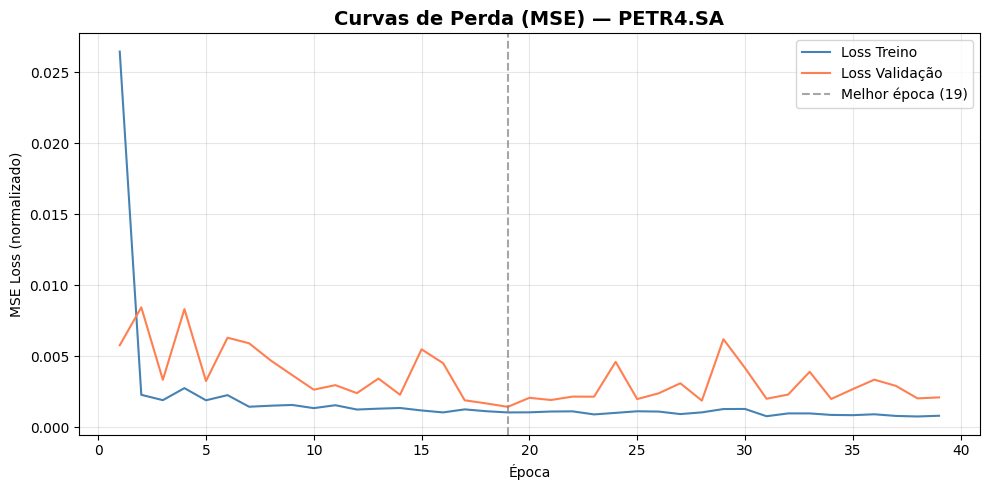

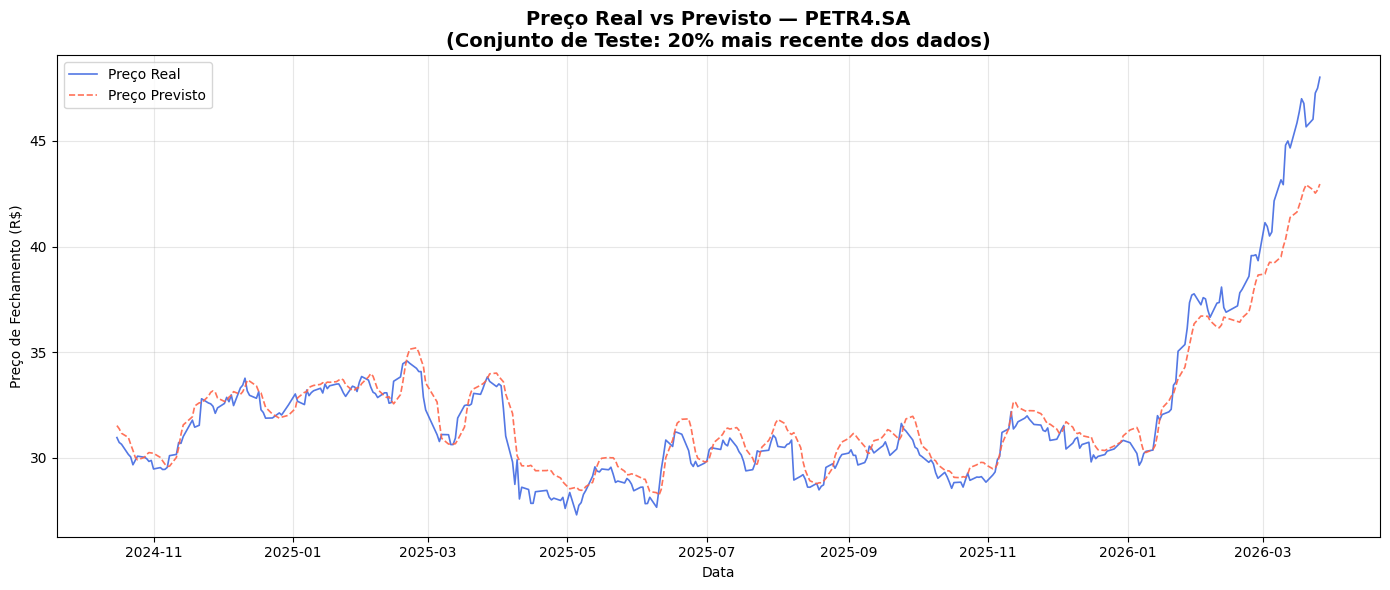

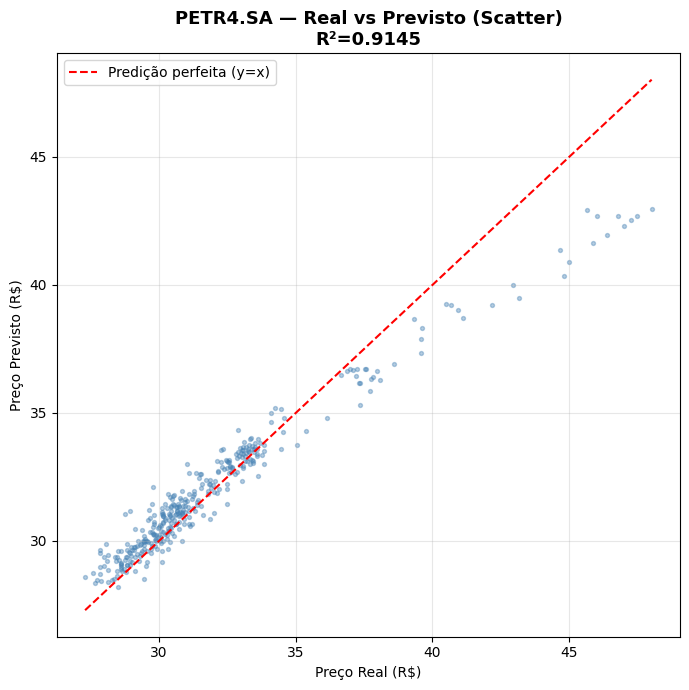


  Previsão dos próximos 7 dias úteis:
    Dia +1: R$ 43.34  (confiabilidade alta)
    Dia +2: R$ 43.38  (confiabilidade alta)
    Dia +3: R$ 43.32  (confiabilidade alta)
    Dia +4: R$ 43.22  (confiabilidade moderada)
    Dia +5: R$ 43.12  (confiabilidade moderada)
    Dia +6: R$ 43.04  (confiabilidade indicativa)
    Dia +7: R$ 42.99  (confiabilidade indicativa)


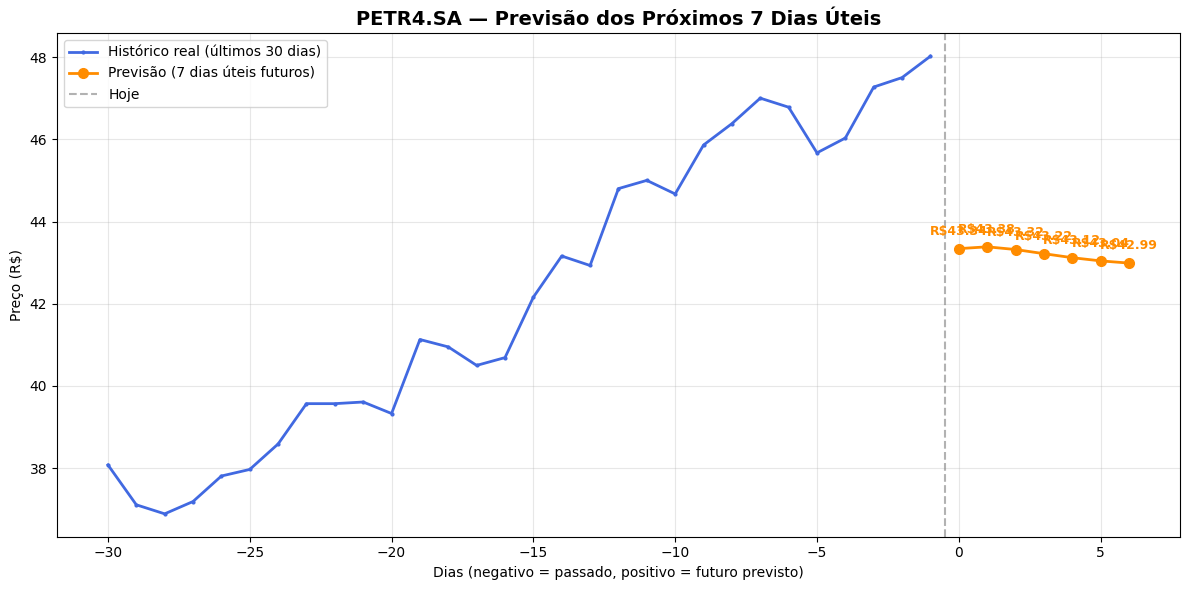


############################################################
# PROCESSANDO: BBAS3.SA
############################################################

  Baixando dados para BBAS3.SA...
  Dados: 2019-01-21 → 2026-03-26 (1787 dias úteis)
  Features: ['Close', 'SMA_14', 'EMA_14', 'RSI_14']
  Split: 1429 treino | 358 teste
  Scaler ajustado apenas nos dados de treino (anti-leakage)
  Amostras de treino: 1369 | Teste: 358
  Parâmetros treináveis: 238,017

  Treinando BBAS3.SA...
  Época   1/150 | Train: 0.069695 | Val: 0.023456 | LR: 0.001000 | Sem melhora: 0/20
  Época  10/150 | Train: 0.003318 | Val: 0.002258 | LR: 0.001000 | Sem melhora: 1/20
  Época  20/150 | Train: 0.001899 | Val: 0.001156 | LR: 0.001000 | Sem melhora: 0/20
  Época  30/150 | Train: 0.001909 | Val: 0.001242 | LR: 0.001000 | Sem melhora: 3/20
  Época  40/150 | Train: 0.001613 | Val: 0.000884 | LR: 0.001000 | Sem melhora: 0/20
  Época  50/150 | Train: 0.001473 | Val: 0.001119 | LR: 0.001000 | Sem melhora: 10/20
  Época  60/1

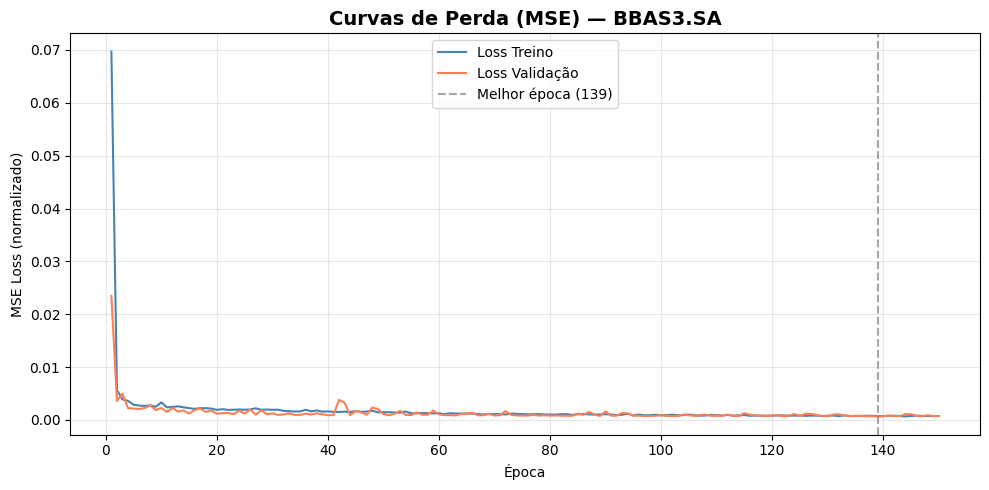

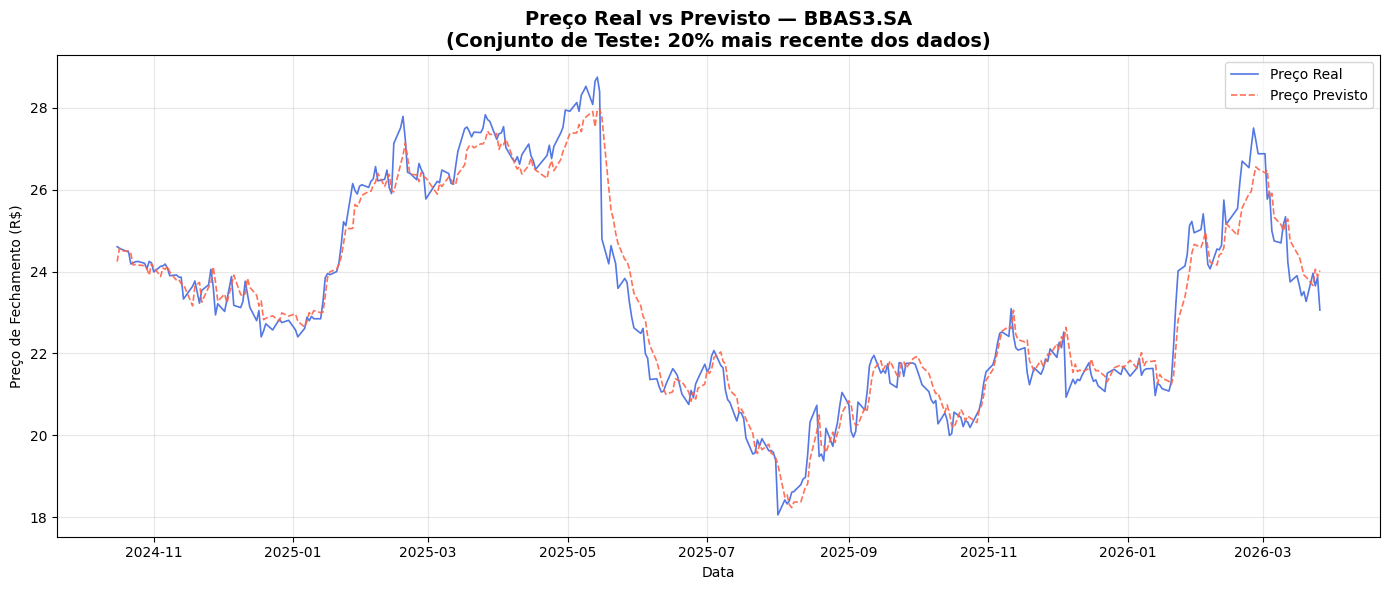

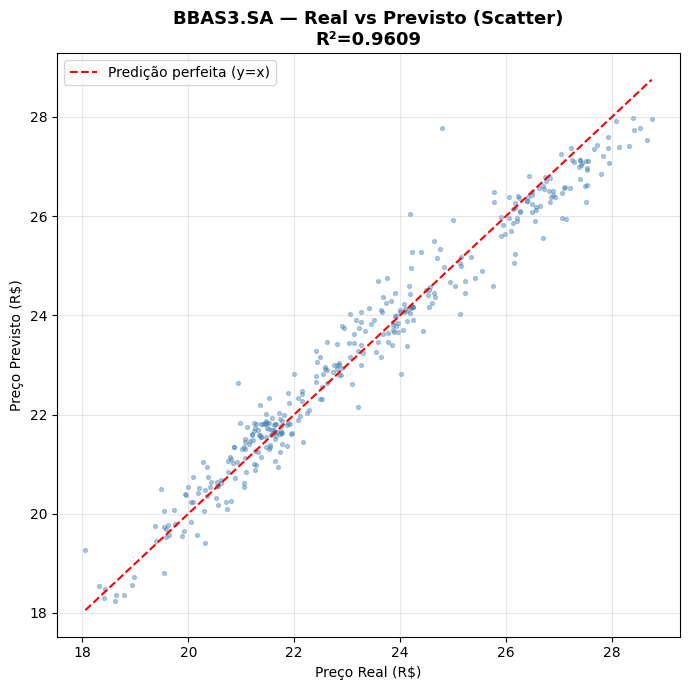


  Previsão dos próximos 7 dias úteis:
    Dia +1: R$ 23.60  (confiabilidade alta)
    Dia +2: R$ 23.63  (confiabilidade alta)
    Dia +3: R$ 23.63  (confiabilidade alta)
    Dia +4: R$ 23.65  (confiabilidade moderada)
    Dia +5: R$ 23.66  (confiabilidade moderada)
    Dia +6: R$ 23.66  (confiabilidade indicativa)
    Dia +7: R$ 23.66  (confiabilidade indicativa)


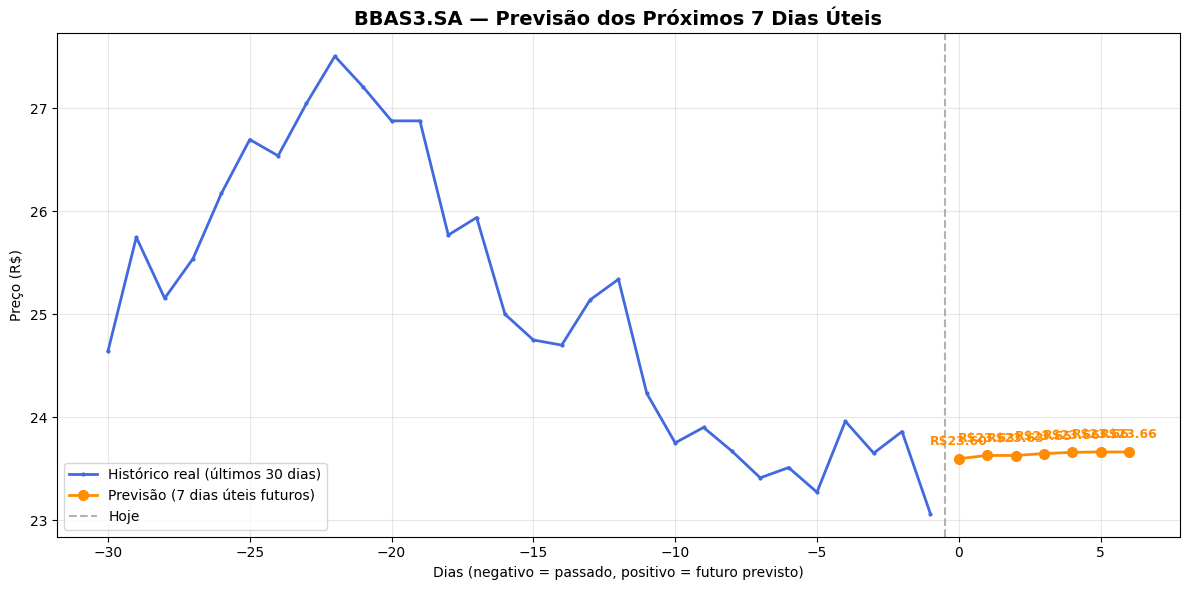


############################################################
# PROCESSANDO: WEGE3.SA
############################################################

  Baixando dados para WEGE3.SA...
  Dados: 2019-01-21 → 2026-03-26 (1787 dias úteis)
  Features: ['Close', 'SMA_14', 'EMA_14', 'RSI_14']
  Split: 1429 treino | 358 teste
  Scaler ajustado apenas nos dados de treino (anti-leakage)
  Amostras de treino: 1369 | Teste: 358
  Parâmetros treináveis: 238,017

  Treinando WEGE3.SA...
  Época   1/150 | Train: 0.067127 | Val: 0.003586 | LR: 0.001000 | Sem melhora: 0/20
  Época  10/150 | Train: 0.002412 | Val: 0.001688 | LR: 0.001000 | Sem melhora: 1/20
  Época  20/150 | Train: 0.002081 | Val: 0.000855 | LR: 0.001000 | Sem melhora: 2/20
  Época  30/150 | Train: 0.001723 | Val: 0.000926 | LR: 0.001000 | Sem melhora: 6/20
  Época  40/150 | Train: 0.001904 | Val: 0.000686 | LR: 0.001000 | Sem melhora: 2/20
  Época  50/150 | Train: 0.001457 | Val: 0.000666 | LR: 0.001000 | Sem melhora: 5/20
  Época  60/15

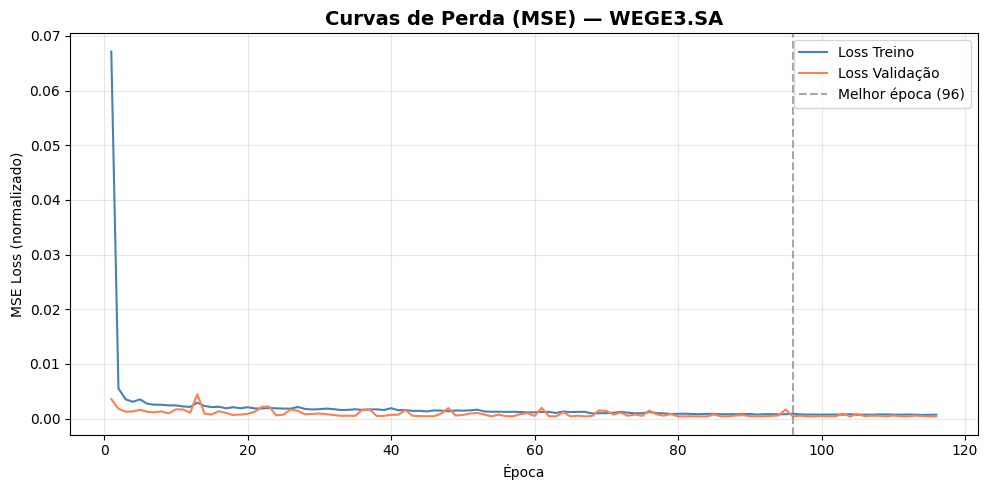

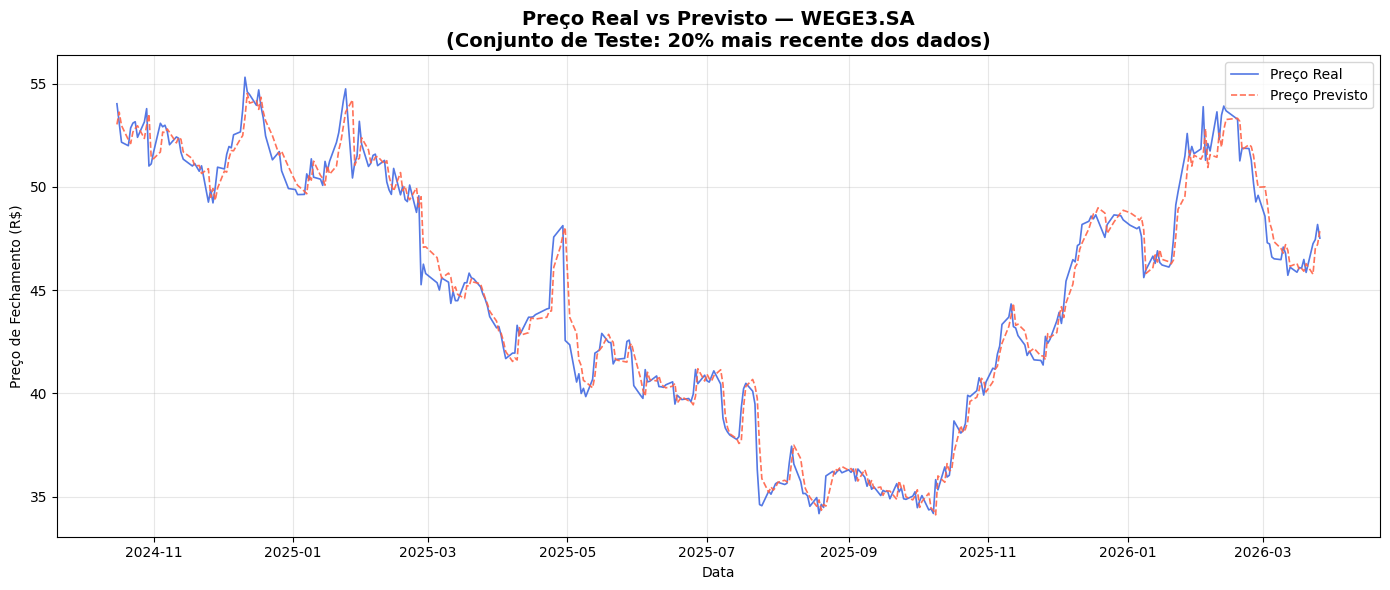

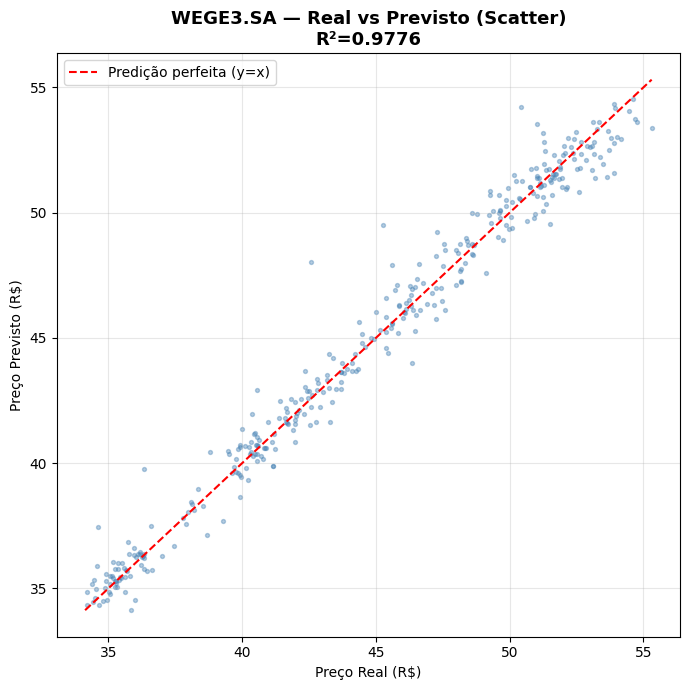


  Previsão dos próximos 7 dias úteis:
    Dia +1: R$ 47.39  (confiabilidade alta)
    Dia +2: R$ 47.34  (confiabilidade alta)
    Dia +3: R$ 47.27  (confiabilidade alta)
    Dia +4: R$ 47.17  (confiabilidade moderada)
    Dia +5: R$ 47.08  (confiabilidade moderada)
    Dia +6: R$ 47.00  (confiabilidade indicativa)
    Dia +7: R$ 46.94  (confiabilidade indicativa)


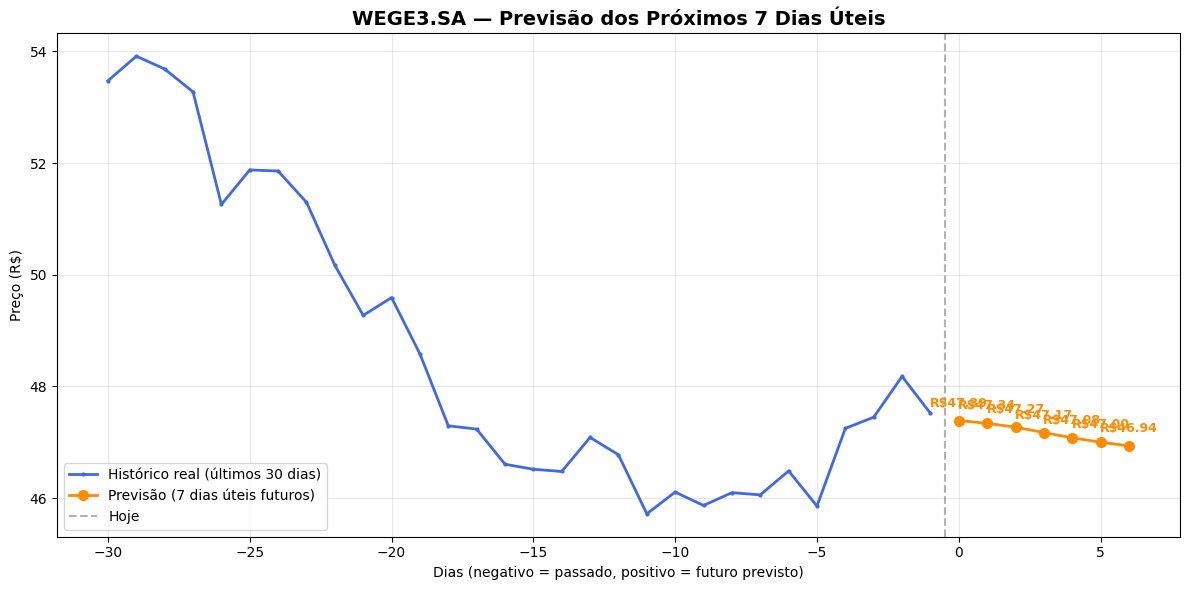


############################################################
# PROCESSANDO: ABEV3.SA
############################################################

  Baixando dados para ABEV3.SA...
  Dados: 2019-01-21 → 2026-03-26 (1787 dias úteis)
  Features: ['Close', 'SMA_14', 'EMA_14', 'RSI_14']
  Split: 1429 treino | 358 teste
  Scaler ajustado apenas nos dados de treino (anti-leakage)
  Amostras de treino: 1369 | Teste: 358
  Parâmetros treináveis: 238,017

  Treinando ABEV3.SA...
  Época   1/150 | Train: 0.031360 | Val: 0.009619 | LR: 0.001000 | Sem melhora: 0/20
  Época  10/150 | Train: 0.003506 | Val: 0.001318 | LR: 0.001000 | Sem melhora: 0/20
  Época  20/150 | Train: 0.002462 | Val: 0.001253 | LR: 0.001000 | Sem melhora: 4/20
  Época  30/150 | Train: 0.002109 | Val: 0.001123 | LR: 0.001000 | Sem melhora: 3/20
  Época  40/150 | Train: 0.001949 | Val: 0.001150 | LR: 0.001000 | Sem melhora: 2/20
  Época  50/150 | Train: 0.001696 | Val: 0.001209 | LR: 0.000500 | Sem melhora: 12/20 [LR reduzido:

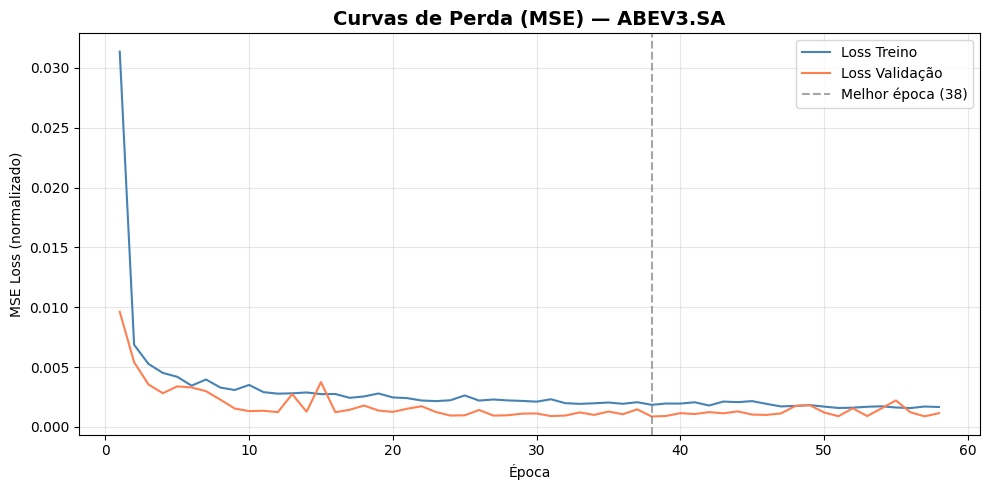

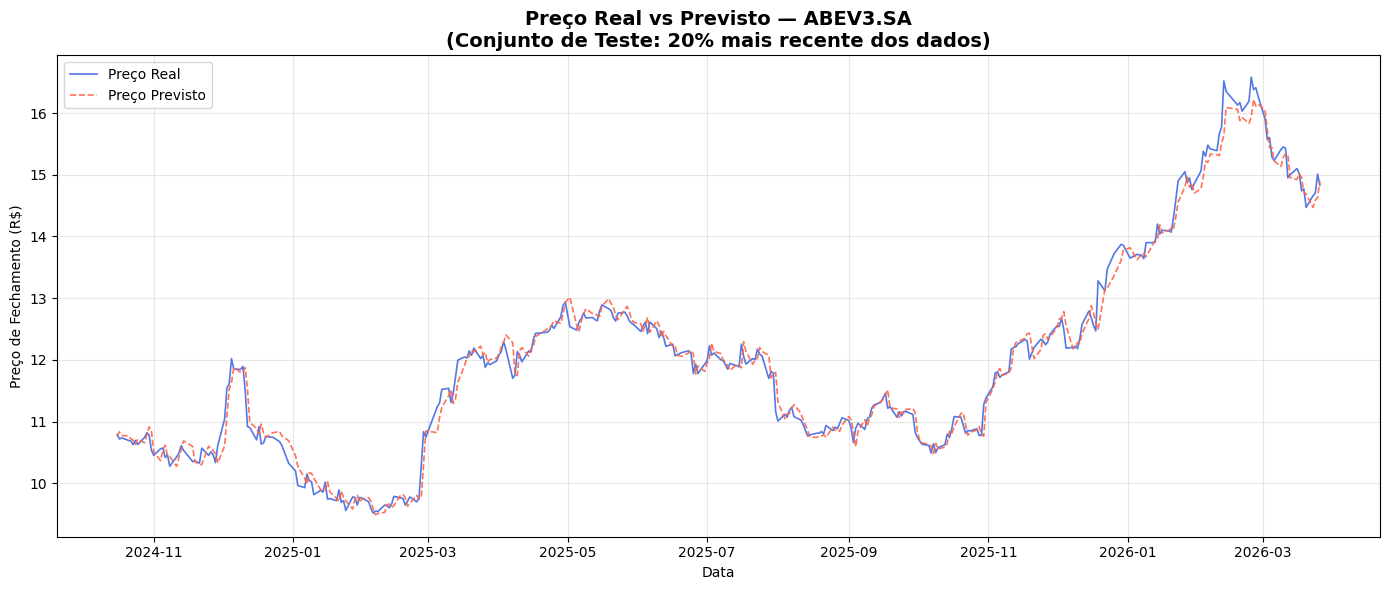

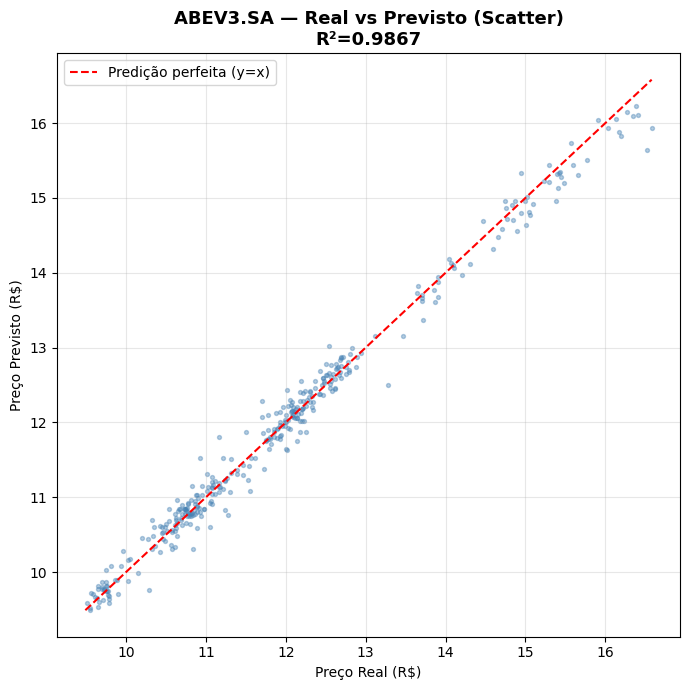


  Previsão dos próximos 7 dias úteis:
    Dia +1: R$ 14.78  (confiabilidade alta)
    Dia +2: R$ 14.72  (confiabilidade alta)
    Dia +3: R$ 14.69  (confiabilidade alta)
    Dia +4: R$ 14.67  (confiabilidade moderada)
    Dia +5: R$ 14.65  (confiabilidade moderada)
    Dia +6: R$ 14.63  (confiabilidade indicativa)
    Dia +7: R$ 14.62  (confiabilidade indicativa)


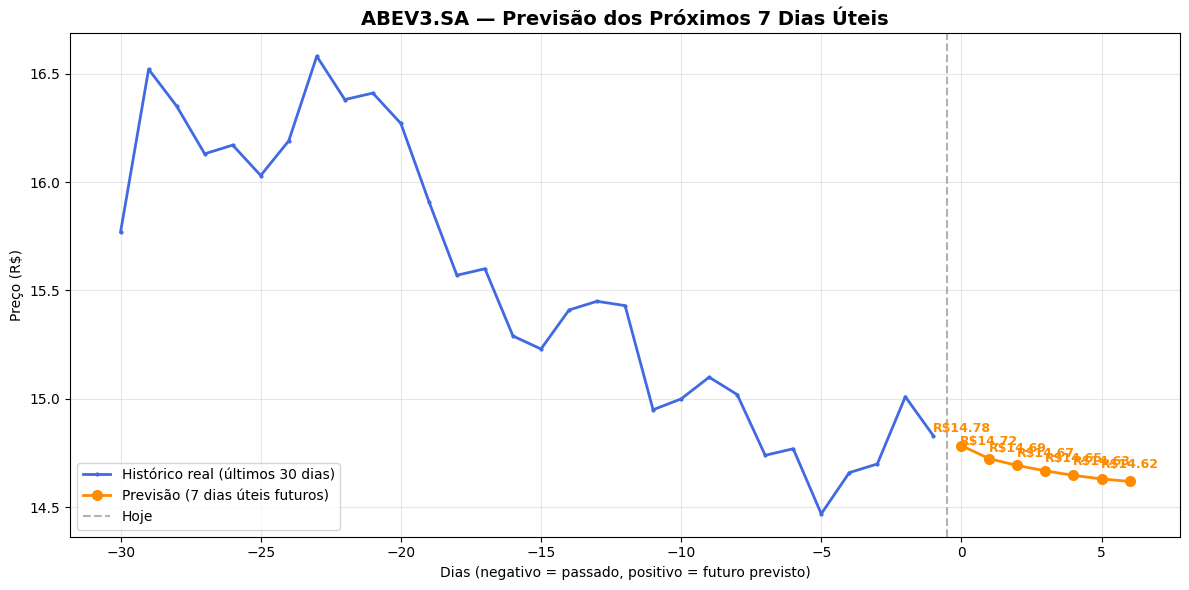

In [55]:
# =============================================================================
# PIPELINE PRINCIPAL
# =============================================================================

def inverter_escala_close(valores_norm, scaler):
    """
    Inverte a normalização apenas para a coluna Close (index 0).

    O scaler foi ajustado em N_FEATURES=4 colunas — para inverter
    corretamente, precisamos passar um array com as 4 colunas.
    Preenchemos as outras 3 colunas com zeros (serão ignoradas).
    """
    dummy = np.zeros((len(valores_norm), N_FEATURES))
    dummy[:, 0] = valores_norm
    return scaler.inverse_transform(dummy)[:, 0]


def pipeline_completo():
    """
    Executa o pipeline de ponta a ponta para todos os tickers em TICKERS.

    Returns:
        resultados_gerais: dict {ticker: {'MAE', 'RMSE', 'MAPE', 'R2', 'futuro'}}
    """
    resultados_gerais = {}

    for ticker in TICKERS:
        print(f"\n{'#'*60}")
        print(f"# PROCESSANDO: {ticker}")
        print(f"{'#'*60}")

        # ── PASSO 1: DADOS ────────────────────────────────────────────────────
        df = baixar_e_processar_dados(ticker)

        # ── PASSO 2: NORMALIZAÇÃO E SPLIT ────────────────────────────────────
        train_scaled, test_scaled, scaler, split_idx = normalizar_e_dividir(df)

        # ── PASSO 3: SEQUÊNCIAS ───────────────────────────────────────────────
        # IMPORTANTE: o teste precisa de SEQ_LEN dias de contexto para a
        # primeira janela. Concatenamos os últimos SEQ_LEN do treino + teste
        # para garantir que o primeiro ponto de teste tenha janela completa.
        # Sem isso, perderíamos os primeiros SEQ_LEN=60 pontos do teste.
        dados_completos = np.vstack([train_scaled, test_scaled])
        X_treino, y_treino = criar_sequencias(train_scaled, SEQ_LEN)
        X_teste, y_teste   = criar_sequencias(
            dados_completos[split_idx - SEQ_LEN:], SEQ_LEN
        )

        print(f"  Amostras de treino: {len(X_treino)} | Teste: {len(X_teste)}")

        # ── PASSO 4: DATALOADERS ──────────────────────────────────────────────
        # shuffle=True no treino: evita que a ordem temporal crie viés nos gradientes
        # shuffle=False no teste: manter ordem temporal para plotar com datas
        train_loader = DataLoader(
            AcoesDataset(X_treino, y_treino),
            batch_size=BATCH_SIZE, shuffle=True
        )
        val_loader = DataLoader(
            AcoesDataset(X_teste, y_teste),
            batch_size=BATCH_SIZE, shuffle=False
        )

        # ── PASSO 5: MODELO ───────────────────────────────────────────────────
        model = LSTMGRUModel(
            N_FEATURES, HIDDEN_LSTM, HIDDEN_GRU, NUM_LAYERS_LSTM, DROPOUT
        ).to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parâmetros treináveis: {n_params:,}")

        # ── PASSO 6: TREINAMENTO ──────────────────────────────────────────────
        print(f"\n  Treinando {ticker}...")
        historico = treinar_modelo(model, train_loader, val_loader, ticker)

        # ── PASSO 7: PREDIÇÕES NO TESTE ───────────────────────────────────────
        model.eval()
        previsoes_norm = []
        with torch.no_grad():
            for X_batch, _ in val_loader:
                pred = model(X_batch.to(DEVICE))
                previsoes_norm.extend(pred.cpu().numpy())
        previsoes_norm = np.array(previsoes_norm)

        # ── PASSO 8: INVERSÃO DA NORMALIZAÇÃO ────────────────────────────────
        y_pred_real = inverter_escala_close(previsoes_norm, scaler)
        y_real_real = inverter_escala_close(y_teste, scaler)

        # Alinhamento de tamanhos e datas do conjunto de teste
        datas_teste = df.index[split_idx:]
        n = min(len(y_pred_real), len(y_real_real), len(datas_teste))
        y_pred_real = y_pred_real[:n]
        y_real_real = y_real_real[:n]
        datas_teste = datas_teste[:n]

        # ── PASSO 9: MÉTRICAS ─────────────────────────────────────────────────
        metricas = calcular_metricas(y_real_real, y_pred_real, ticker)
        resultados_gerais[ticker] = metricas

        # ── PASSO 10: VISUALIZAÇÕES ───────────────────────────────────────────
        plotar_curvas_perda(historico, ticker)
        plotar_previsoes(y_real_real, y_pred_real, datas_teste, ticker)
        plotar_scatter(y_real_real, y_pred_real, ticker, metricas['R2'])

        # ── PASSO 11: PREVISÃO FUTURA ─────────────────────────────────────────
        print(f"\n  Previsão dos próximos {N_FUTURE} dias úteis:")
        precos_futuros = prever_futuro(model, df, scaler)
        for i, p in enumerate(precos_futuros, 1):
            confianca = 'alta' if i <= 3 else 'moderada' if i <= 5 else 'indicativa'
            print(f"    Dia +{i}: R$ {p:.2f}  (confiabilidade {confianca})")
        plotar_futuro(df, precos_futuros, ticker)

        resultados_gerais[ticker]['futuro'] = precos_futuros

    return resultados_gerais


# Executar o pipeline completo
resultados = pipeline_completo()

In [56]:
# =============================================================================
# TABELA COMPARATIVA FINAL
# =============================================================================

def plotar_tabela_comparativa(resultados):
    """
    Exibe tabela resumo com métricas de todos os ativos e interpretação
    direcionada ao assessor de investimentos.
    """
    print("\n" + "="*72)
    print("  RESUMO COMPARATIVO — 4 AÇÕES DA B3")
    print("="*72)
    print(f"{'Ativo':<12} {'MAE (R$)':>10} {'RMSE (R$)':>11} {'MAPE (%)':>10} {'R²':>8}  {'Meta R²>0.83':>14}")
    print("-"*72)

    for ticker, m in resultados.items():
        status = '✅ ATINGIDA' if m['R2'] >= 0.83 else '❌ ABAIXO'
        print(f"{ticker:<12} {m['MAE']:>10.4f} {m['RMSE']:>11.4f} "
              f"{m['MAPE']:>10.2f} {m['R2']:>8.4f}  {status:>14}")

    print("="*72)

    melhor_r2    = max(resultados, key=lambda t: resultados[t]['R2'])
    menor_mape   = min(resultados, key=lambda t: resultados[t]['MAPE'])
    menor_mae    = min(resultados, key=lambda t: resultados[t]['MAE'])

    print(f"\n  Mais previsível (maior R²):     {melhor_r2}  "
          f"(R²={resultados[melhor_r2]['R2']:.4f})")
    print(f"  Menor erro relativo (MAPE):     {menor_mape}  "
          f"(MAPE={resultados[menor_mape]['MAPE']:.2f}%)")
    print(f"  Menor erro absoluto (MAE):      {menor_mae}  "
          f"(MAE=R${resultados[menor_mae]['MAE']:.4f})")

    print("""
  INTERPRETAÇÃO PARA O ASSESSOR DE INVESTIMENTOS:
  ─────────────────────────────────────────────────
  • O ativo com maior R² é o mais "previsível" pelo modelo — seus padrões
    históricos se repetem com mais regularidade e o modelo os captura bem.

  • O ativo com menor MAPE tem o menor erro percentual médio — independente
    do nível de preço (R$14 vs R$40), o modelo erra proporcionalmente menos.

  • RMSE >> MAE em algum ativo indica que o modelo "trava" em dias de
    volatilidade extrema (ex: resultados trimestrais, eventos políticos,
    mudanças na SELIC).

  • Nenhuma métrica garante lucro real — o modelo prevê tendências de preço,
    não reage a eventos imprevisíveis (notícias, crises externas, decisões
    regulatórias). Use como referência complementar à análise fundamentalista.
    """)


plotar_tabela_comparativa(resultados)


  RESUMO COMPARATIVO — 4 AÇÕES DA B3
Ativo          MAE (R$)   RMSE (R$)   MAPE (%)       R²    Meta R²>0.83
------------------------------------------------------------------------
PETR4.SA         0.7483      1.1195       2.21   0.9145      ✅ ATINGIDA
BBAS3.SA         0.3719      0.4988       1.59   0.9609      ✅ ATINGIDA
WEGE3.SA         0.6338      0.9024       1.42   0.9776      ✅ ATINGIDA
ABEV3.SA         0.1388      0.1903       1.15   0.9867      ✅ ATINGIDA

  Mais previsível (maior R²):     ABEV3.SA  (R²=0.9867)
  Menor erro relativo (MAPE):     ABEV3.SA  (MAPE=1.15%)
  Menor erro absoluto (MAE):      ABEV3.SA  (MAE=R$0.1388)

  INTERPRETAÇÃO PARA O ASSESSOR DE INVESTIMENTOS:
  ─────────────────────────────────────────────────
  • O ativo com maior R² é o mais "previsível" pelo modelo — seus padrões
    históricos se repetem com mais regularidade e o modelo os captura bem.

  • O ativo com menor MAPE tem o menor erro percentual médio — independente
    do nível de preço (R$14

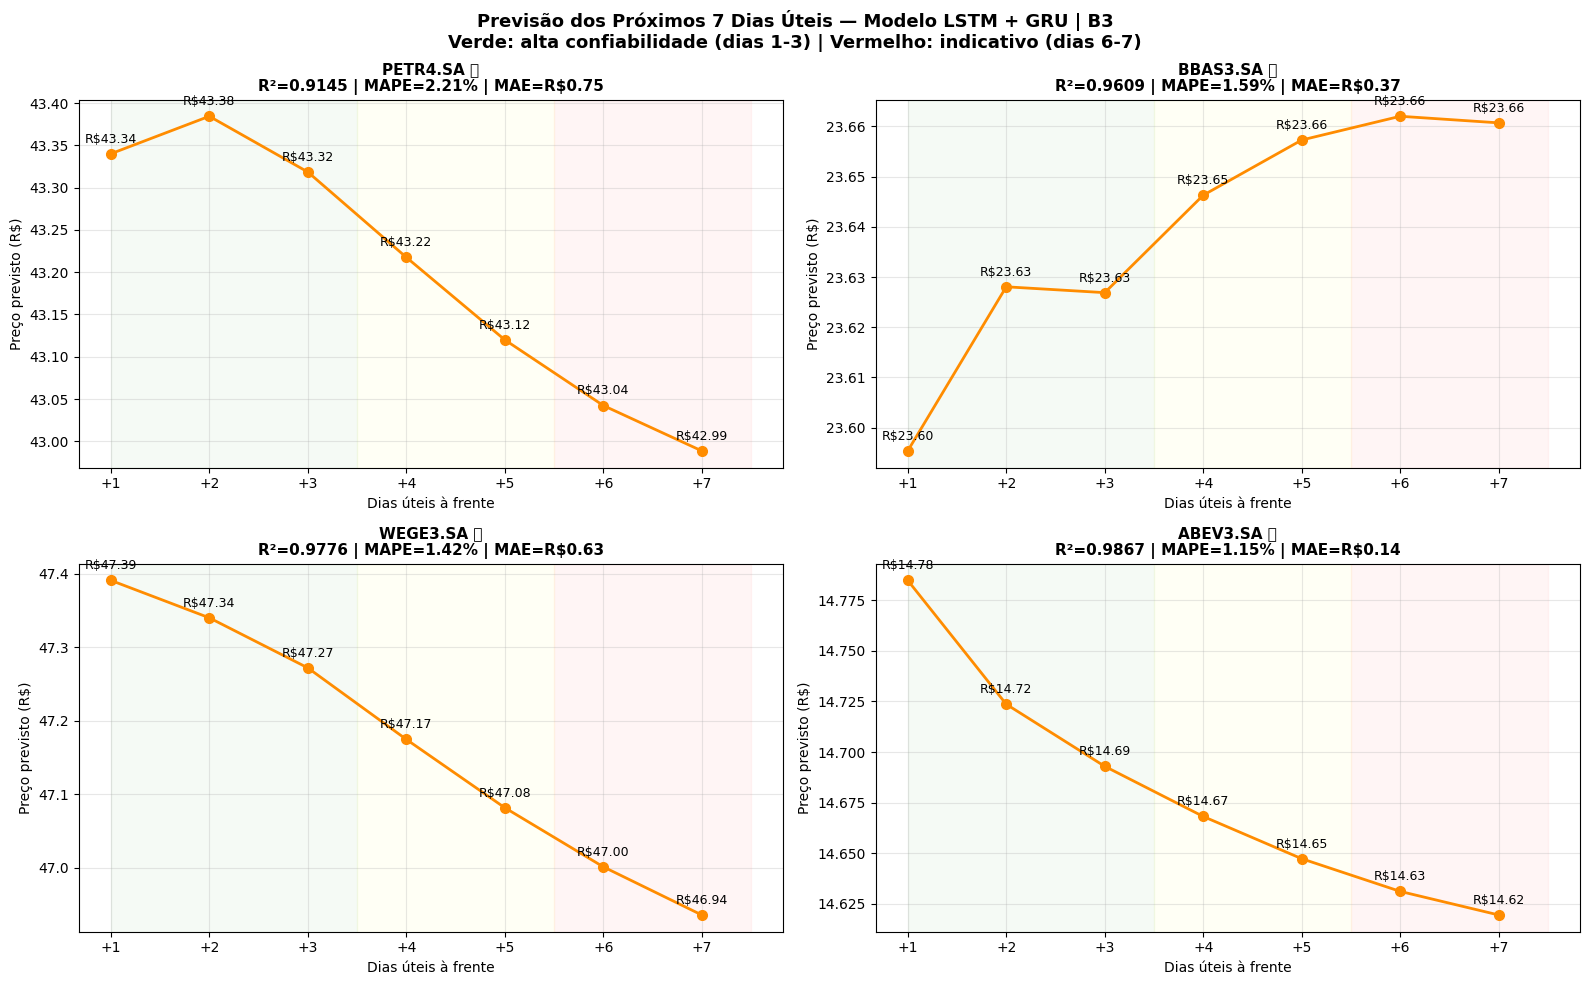

Gráfico consolidado salvo: previsoes_futuras_consolidado.png


In [57]:
# =============================================================================
# VISUALIZAÇÃO CONSOLIDADA — 4 PREVISÕES FUTURAS (PITCH)
# =============================================================================

# Gráfico 2x2: ideal para apresentação/pitch — todas as previsões em uma slide
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    futuro = resultados[ticker]['futuro']
    m = resultados[ticker]

    # Linha de previsão futura
    ax.plot(
        range(1, N_FUTURE + 1), futuro,
        marker='o', color='darkorange', linewidth=2, markersize=7
    )

    # Anotações de preço em cada ponto
    for j, p in enumerate(futuro):
        ax.annotate(
            f'R${p:.2f}', (j + 1, p),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=9
        )

    # Faixa de confiabilidade (visual)
    ax.axvspan(1, 3.5, alpha=0.04, color='green', label='Alta confiabilidade')
    ax.axvspan(3.5, 5.5, alpha=0.04, color='yellow')
    ax.axvspan(5.5, N_FUTURE + 0.5, alpha=0.04, color='red', label='Indicativo')

    meta_status = '✅' if m['R2'] >= 0.83 else '❌'
    ax.set_title(
        f'{ticker} {meta_status}\nR²={m["R2"]:.4f} | MAPE={m["MAPE"]:.2f}% | MAE=R${m["MAE"]:.2f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Dias úteis à frente')
    ax.set_ylabel('Preço previsto (R$)')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, N_FUTURE + 1))
    ax.set_xticklabels([f'+{d}' for d in range(1, N_FUTURE + 1)])

plt.suptitle(
    f'Previsão dos Próximos {N_FUTURE} Dias Úteis — Modelo LSTM + GRU | B3\n'
    f'Verde: alta confiabilidade (dias 1-3) | Vermelho: indicativo (dias 6-7)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('previsoes_futuras_consolidado.png', dpi=120)
plt.show()
plt.close()

print("Gráfico consolidado salvo: previsoes_futuras_consolidado.png")

## Conclusões e Limitações


### O que o modelo consegue fazer

- **Capturar tendências de médio prazo** (horizonte de semanas), especialmente em ativos com padrões mais regulares
- **Identificar padrões recorrentes por setor**  sazonalidade de ABEV3, ciclos de BBAS3, tendências de longo prazo de WEGE3
- **Quantificar a previsibilidade relativa** entre ativos, o R² e MAPE permitem comparar objetivamente quais ativos têm comportamento mais regular
- **Fornecer horizonte de curto prazo** (1-3 dias) com razoável confiabilidade para uso como referência quantitativa

---

### O que o modelo NÃO consegue fazer

- **Reagir a eventos imprevisíveis** — notícias de última hora, decisões do COPOM, tweets de CEO, guerras, pandemias
- **Prever reversões abruptas de tendência** — o modelo extrapola padrões passados; quebras estruturais o surpreendem
- **Garantir lucro** — acertar o preço de fechamento não implica acertar a *direção* (alta ou queda), que é o que realmente importa para uma decisão de investimento
- **Capturar regimes de mercado inéditos** — um modelo treinado em 2019-2024 não "sabe" o que não existia nesse período

---

### Por que diferentes ações têm R² diferentes?

| Ativo | Expectativa | Razão |
|-------|-------------|-------|
| WEGE3 | R² mais alto | Industrial estável, crescimento consistente, padrões mais regulares |
| ABEV3 | R² alto | Sazonalidade bem definida, consumo defensivo, menos ruído especulativo |
| BBAS3 | R² médio | Sensível a ciclos de crédito e SELIC — variável mas previsível |
| PETR4 | R² menor | Alta volatilidade, risco político, correlação com commodities globais |

Um R² menor para PETR4 não indica falha do modelo — indica que o ativo tem componentes de imprevisibilidade estrutural que nenhum modelo de ML consegue capturar completamente.

---

### Próximos passos (extensões possíveis)

1. **Attention Mechanism** sobre a saída do LSTM — pesaria mais os dias mais relevantes
2. **Transformer / Temporal Fusion Transformer** — arquitetura state-of-the-art para séries temporais
3. **Features macroeconômicas** — incluir USD/BRL, SELIC, Brent, IBOVESPA como features exógenas
4. **Ensemble** — combinar LSTM+GRU com XGBoost para capturar tanto padrões sequenciais quanto não-lineares
5. **Backtesting** — simular estratégia de trading baseada nas previsões para avaliar retorno real



*Projeto desenvolvido com PyTorch | Dados: Yahoo Finance via yfinance | Período: 2019 – presente*